In [1]:
# load metadata
# metadata
Italy1_curatedmetagenomics_metadata <- read.delim('/Users/zihuahuang/Documents/SSMS/data/metadata/Italy1_metadata.tsv')
Italy1_filereport_read_run <- read.delim('/Users/zihuahuang/Documents/SSMS/data/metadata/Itay1_Italy2_PRJNA447983_tsv.txt')
Italy1_metadata <- merge(x = Italy1_curatedmetagenomics_metadata,
                         y = Italy1_filereport_read_run,
                         by.x = 'subject_id',
                         by.y = 'sample_alias',
                         all.x = TRUE)
Italy2_curatedmetagenomics_metadata <- read.csv('/Users/zihuahuang/Documents/SSMS/data/metadata/Italy2_metadata.csv')
Italy2_metadata <- merge(x = Italy2_curatedmetagenomics_metadata,
                         y = Italy1_filereport_read_run,
                         by.x = 'subject_id',
                         by.y = 'sample_alias',
                         all.x = TRUE)

Austria_metadata <- read.delim('/Users/zihuahuang/Documents/SSMS/data/metadata/Austria_metadata.tsv')

# mgs
Italy2_mgs_pw <- read.csv('data/imputed_pw/predicted_Italy2_mgs_level4ec_relab_unstratified.csv', row.names = 1)
Italy1_mgs_pw <- read.csv('data/imputed_pw/predicted_Italy1_mgs_level4ec_relab_unstratified.csv', row.names = 1)
Austria_mgs_pw <- read.csv('data/imputed_pw/predicted_Austria_mgs_level4ec_relab_unstratified.csv', row.names = 1)

# shallow
Italy2_ssms_pw <- read.csv('data/imputed_pw/predicted_Italy2_500k_level4ec_relab_unstratified.csv', row.names = 1)
Italy1_ssms_pw <- read.csv('data/imputed_pw/predicted_Italy1_500k_level4ec_relab_unstratified.csv', row.names = 1)
Austria_ssms_pw <- read.csv('data/imputed_pw/predicted_Austria_500k_level4ec_relab_unstratified.csv', row.names = 1)

# imputed
predicted_pw_spiec_Austriaasref_Italy2 <- read.csv('data/imputed_pw/spieceasi/predicted_pathway_spiec_Austriaasref_Italy2.csv', row.names = 1)
predicted_pw_spiec_Austriaasref_Italy1 <- read.csv('data/imputed_pw/spieceasi/predicted_pathway_spiec_Austriaasref_Italy1.csv', row.names = 1)
predicted_pw_spiec_Italy1asref_Italy2 <- read.csv('data/imputed_pw/spieceasi/predicted_pathway_spiec_Italy1asref_Italy2.csv', row.names = 1)
predicted_pw_spiec_Italy2asref_Italy1 <- read.csv('data/imputed_pw/spieceasi/predicted_pathway_spiec_Italy2asref_Italy1.csv', row.names = 1)
predicted_pw_spiec_Italy1asref_Austria <- read.csv('data/imputed_pw/spieceasi/predicted_pathway_spiec_Italy1asref_Austria.csv', row.names = 1)
predicted_pw_spiec_Italy2asref_Austria <- read.csv('data/imputed_pw/spieceasi/predicted_pathway_spiec_Italy2asref_Austria.csv', row.names = 1)

dim(predicted_pw_spiec_Austriaasref_Italy2)

[1] 201  58

In [2]:
# normalization and align row
library(dplyr)
library(purrr)

rows_to_remove <- c("UNMAPPED", "UNINTEGRATED")  

Italy2_mgs_pw <- Italy2_mgs_pw[!rownames(Italy2_mgs_pw) %in% rows_to_remove, ]
Italy1_mgs_pw <- Italy1_mgs_pw[!rownames(Italy1_mgs_pw) %in% rows_to_remove, ]
Austria_mgs_pw <- Austria_mgs_pw[!rownames(Austria_mgs_pw) %in% rows_to_remove, ]

Italy2_ssms_pw <- Italy2_ssms_pw[!rownames(Italy2_ssms_pw) %in% rows_to_remove, ]
Italy1_ssms_pw <- Italy1_ssms_pw[!rownames(Italy1_ssms_pw) %in% rows_to_remove, ]
Austria_ssms_pw <- Austria_ssms_pw[!rownames(Austria_ssms_pw) %in% rows_to_remove, ]

# let the sum of each column be 1
Italy2_mgs_pw <- sweep(Italy2_mgs_pw, 2, colSums(Italy2_mgs_pw), FUN = "/")
Italy1_mgs_pw <- sweep(Italy1_mgs_pw, 2, colSums(Italy1_mgs_pw), FUN = "/")
Austria_mgs_pw <- sweep(Austria_mgs_pw, 2, colSums(Austria_mgs_pw), FUN = "/")

Italy2_ssms_pw <- sweep(Italy2_ssms_pw, 2, colSums(Italy2_ssms_pw), FUN = "/")
Italy1_ssms_pw <- sweep(Italy1_ssms_pw, 2, colSums(Italy1_ssms_pw), FUN = "/")
Austria_ssms_pw <- sweep(Austria_ssms_pw, 2, colSums(Austria_ssms_pw), FUN = "/")

predicted_pw_spiec_Austriaasref_Italy2 <- sweep(predicted_pw_spiec_Austriaasref_Italy2, 2, colSums(predicted_pw_spiec_Austriaasref_Italy2), FUN = "/")
predicted_pw_spiec_Austriaasref_Italy1 <- sweep(predicted_pw_spiec_Austriaasref_Italy1, 2, colSums(predicted_pw_spiec_Austriaasref_Italy1), FUN = "/")
predicted_pw_spiec_Italy1asref_Italy2 <- sweep(predicted_pw_spiec_Italy1asref_Italy2, 2, colSums(predicted_pw_spiec_Italy1asref_Italy2), FUN = "/")
predicted_pw_spiec_Italy2asref_Italy1 <- sweep(predicted_pw_spiec_Italy2asref_Italy1, 2, colSums(predicted_pw_spiec_Italy2asref_Italy1), FUN = "/")
predicted_pw_spiec_Italy1asref_Austria <- sweep(predicted_pw_spiec_Italy1asref_Austria, 2, colSums(predicted_pw_spiec_Italy1asref_Austria), FUN = "/")
predicted_pw_spiec_Italy2asref_Austria <- sweep(predicted_pw_spiec_Italy2asref_Austria, 2, colSums(predicted_pw_spiec_Italy2asref_Austria), FUN = "/")


# alignment
dfs <- list(Italy1_mgs_pw = Italy1_mgs_pw, 
            Italy2_mgs_pw = Italy2_mgs_pw, 
            Austria_mgs_pw = Austria_mgs_pw,
           Italy1_ssms_pw = Italy1_ssms_pw,
           Italy2_ssms_pw = Italy2_ssms_pw, 
           Austria_ssms_pw = Austria_ssms_pw, 
            predicted_pw_spiec_Austriaasref_Italy2 = predicted_pw_spiec_Austriaasref_Italy2,
           predicted_pw_spiec_Austriaasref_Italy1 = predicted_pw_spiec_Austriaasref_Italy1,
           predicted_pw_spiec_Italy1asref_Italy2 =predicted_pw_spiec_Italy1asref_Italy2,
           predicted_pw_spiec_Italy2asref_Italy1 = predicted_pw_spiec_Italy2asref_Italy1,
           predicted_pw_spiec_Italy1asref_Austria = predicted_pw_spiec_Italy1asref_Austria,
           predicted_pw_spiec_Italy2asref_Austria = predicted_pw_spiec_Italy2asref_Austria 
            )

# find all unique row names
dfs <- lapply(dfs, function(df) {
  rownames(df) <- sub(":.*", "", rownames(df))
  return(df)
})
all_rownames <- unique(unlist(lapply(dfs, rownames)))

# allign data frames to have the same rows
align_df <- function(df, all_rows) {
  df_aligned <- df %>% 
    tibble::rownames_to_column("rowname") %>%
    right_join(data.frame(rowname = all_rows), by = "rowname") %>%
    replace(is.na(.), 0) %>%
    tibble::column_to_rownames("rowname")
  return(df_aligned)
}

# align and sort
dfs_aligned <- imap(dfs, ~ align_df(.x, all_rows = all_rownames))
dfs_aligned <- lapply(dfs_aligned, function(df) df[order(rownames(df)), ])
names(dfs_aligned)
dim(dfs_aligned$Italy2_mgs_pw)
dim(dfs_aligned$Italy2_ssms_pw)
#str(dfs_aligned$Italy1_mgs_pw)


Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"Paket 'purrr' wurde unter R Version 4.4.1 erstellt"


[1] "Italy1_mgs_pw"                         
 [2] "Italy2_mgs_pw"                         
 [3] "Austria_mgs_pw"                        
 [4] "Italy1_ssms_pw"                        
 [5] "Italy2_ssms_pw"                        
 [6] "Austria_ssms_pw"                       
 [7] "predicted_pw_spiec_Austriaasref_Italy2"
 [8] "predicted_pw_spiec_Austriaasref_Italy1"
 [9] "predicted_pw_spiec_Italy1asref_Italy2" 
[10] "predicted_pw_spiec_Italy2asref_Italy1" 
[11] "predicted_pw_spiec_Italy1asref_Austria"
[12] "predicted_pw_spiec_Italy2asref_Austria"

[1] 203  58

[1] 203  58

Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.1 erstellt"


'data.frame':	203 obs. of  58 variables:
 $ SRR6915103_merged_Abundance.RPKs: num  0.00822 0.00785 0.01299 0.00093 0.01149 ...
 $ SRR6915104_merged_Abundance.RPKs: num  0.00922 0.00393 0.01166 0.00274 0.00992 ...
 $ SRR6915105_merged_Abundance.RPKs: num  0.00969 0.00393 0.01409 0.00094 0.0131 ...
 $ SRR6915106_merged_Abundance.RPKs: num  6.82e-03 6.86e-03 9.47e-03 7.85e-05 8.68e-03 ...
 $ SRR6915107_merged_Abundance.RPKs: num  0.0104 0.00336 0.01302 0.00228 0.01148 ...
 $ SRR6915108_merged_Abundance.RPKs: num  0.00969 0.00249 0.01325 0.00277 0.01202 ...
 $ SRR6915109_merged_Abundance.RPKs: num  0.00867 0.00627 0.01164 0.00154 0.01113 ...
 $ SRR6915110_merged_Abundance.RPKs: num  0.0097 0.00391 0.01228 0.00433 0.00985 ...
 $ SRR6915111_merged_Abundance.RPKs: num  0.01003 0.00631 0.01173 0.00463 0.00787 ...
 $ SRR6915112_merged_Abundance.RPKs: num  0.00891 0.00422 0.01302 0.00162 0.01207 ...
 $ SRR6915114_merged_Abundance.RPKs: num  0.00915 0.00472 0.0118 0.00388 0.00971 ...
 $ SRR691511

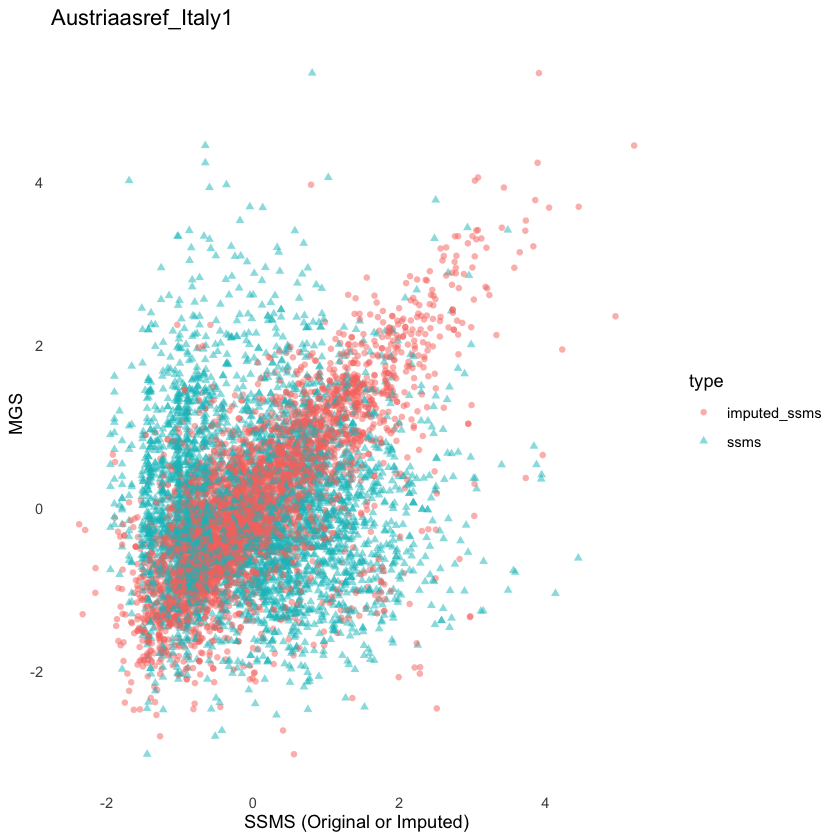

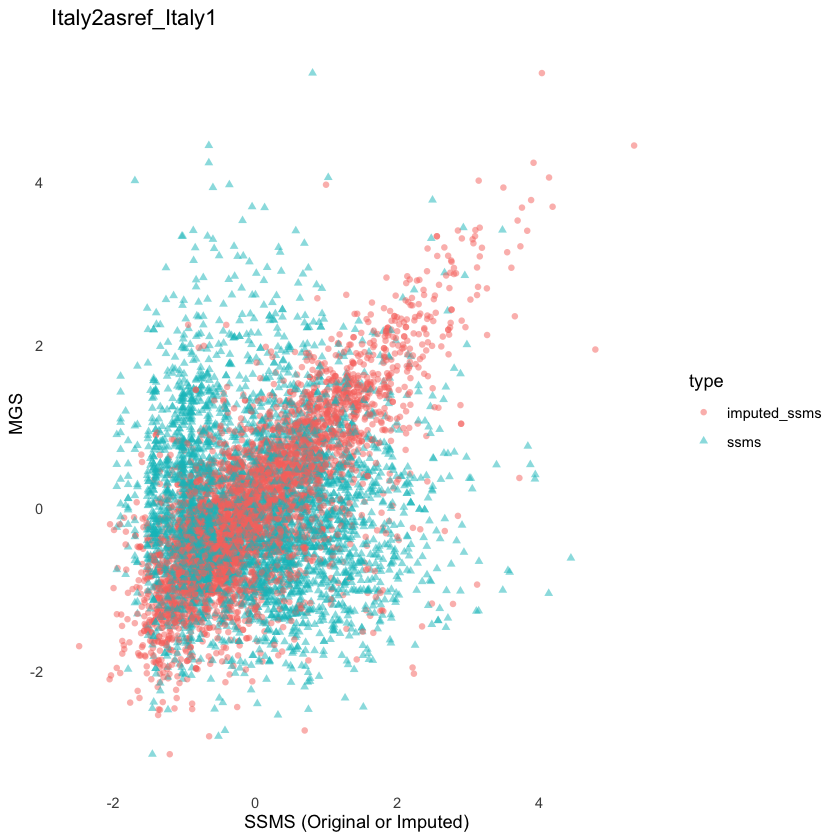

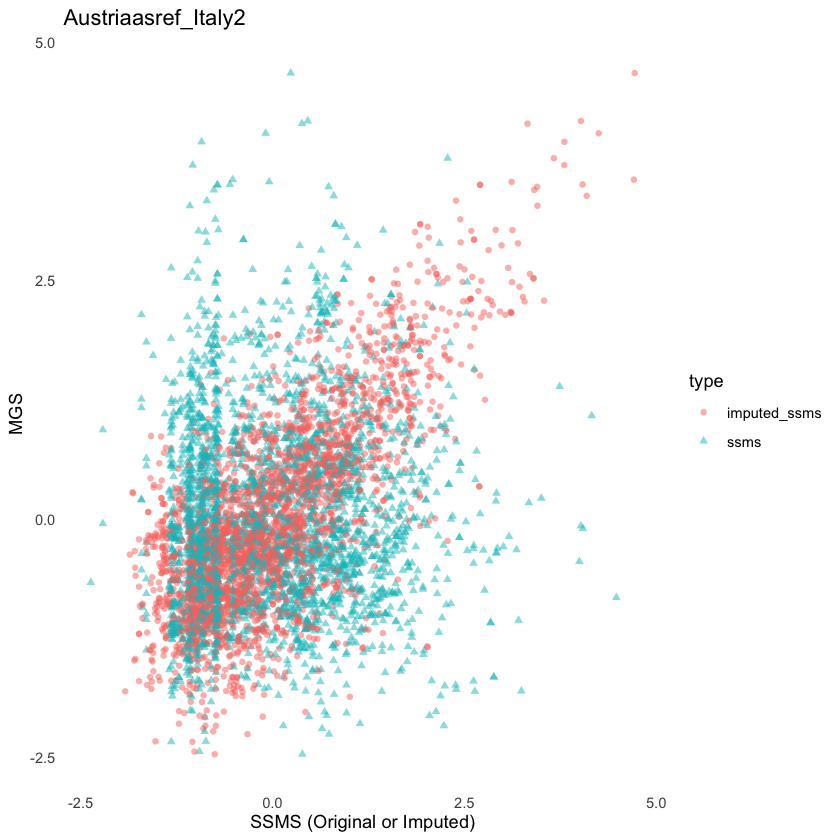

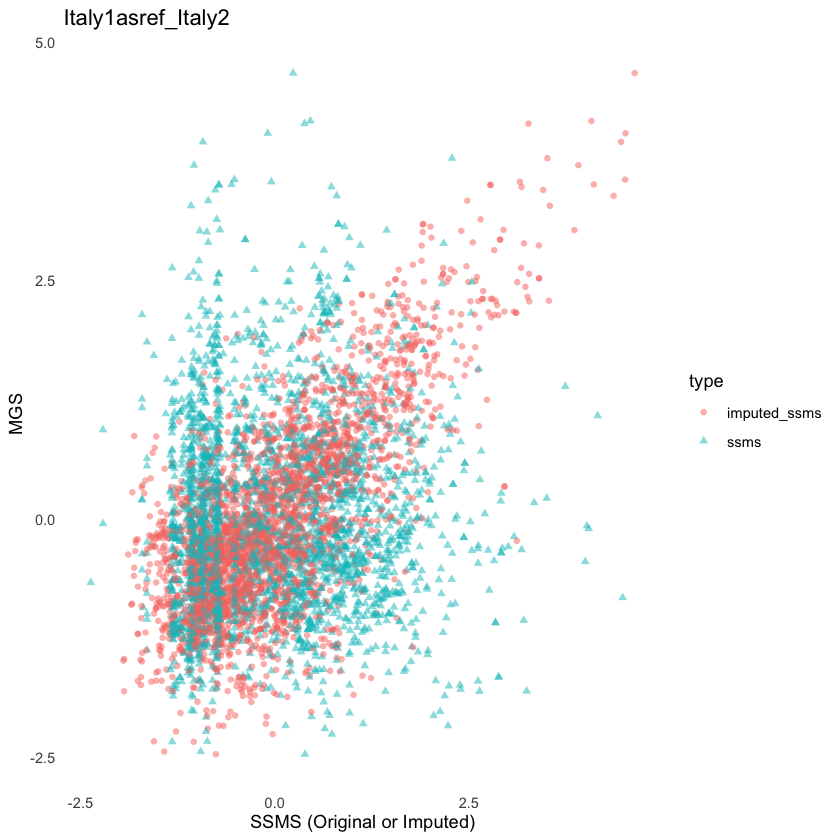

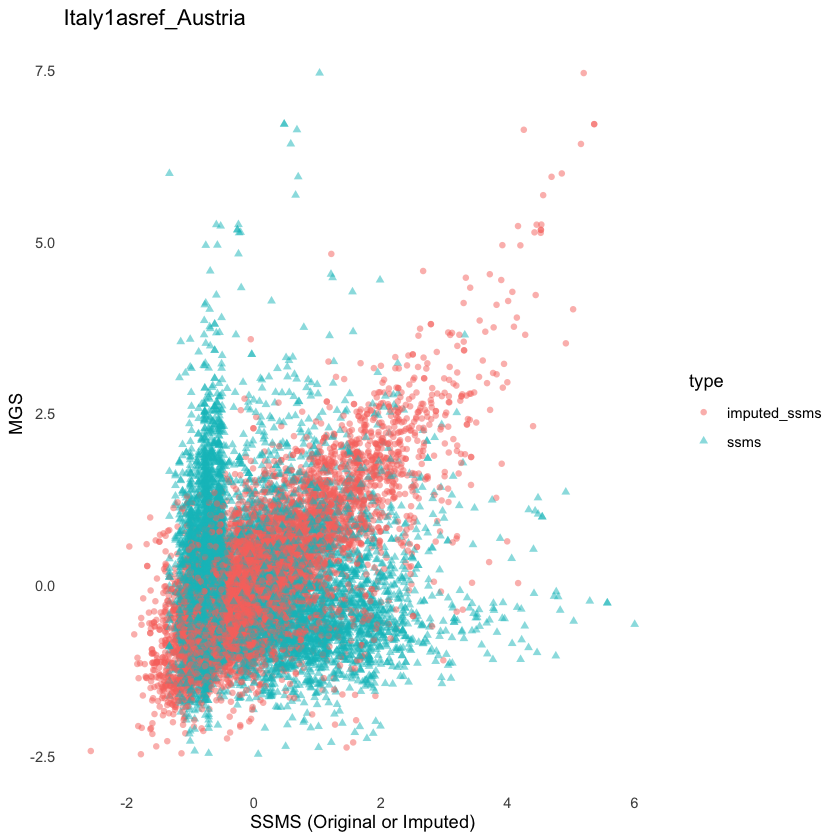

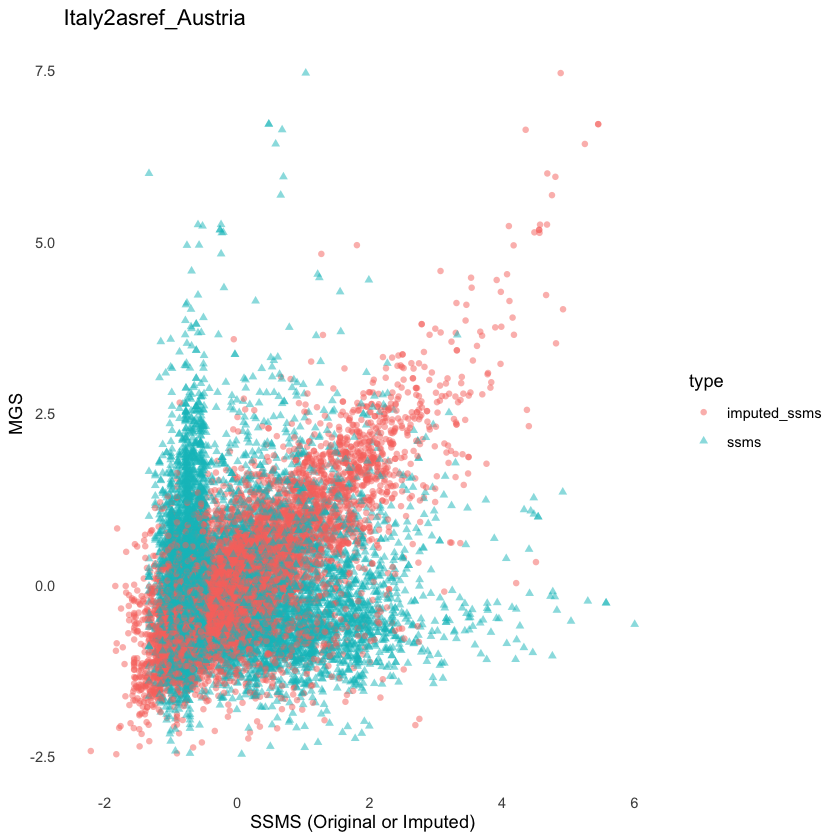

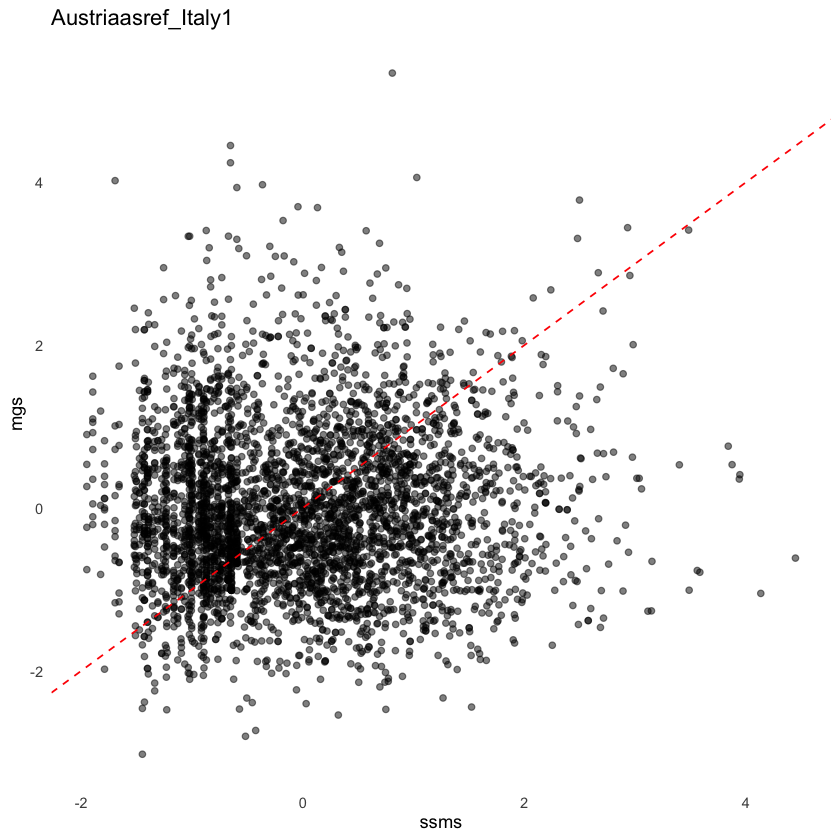

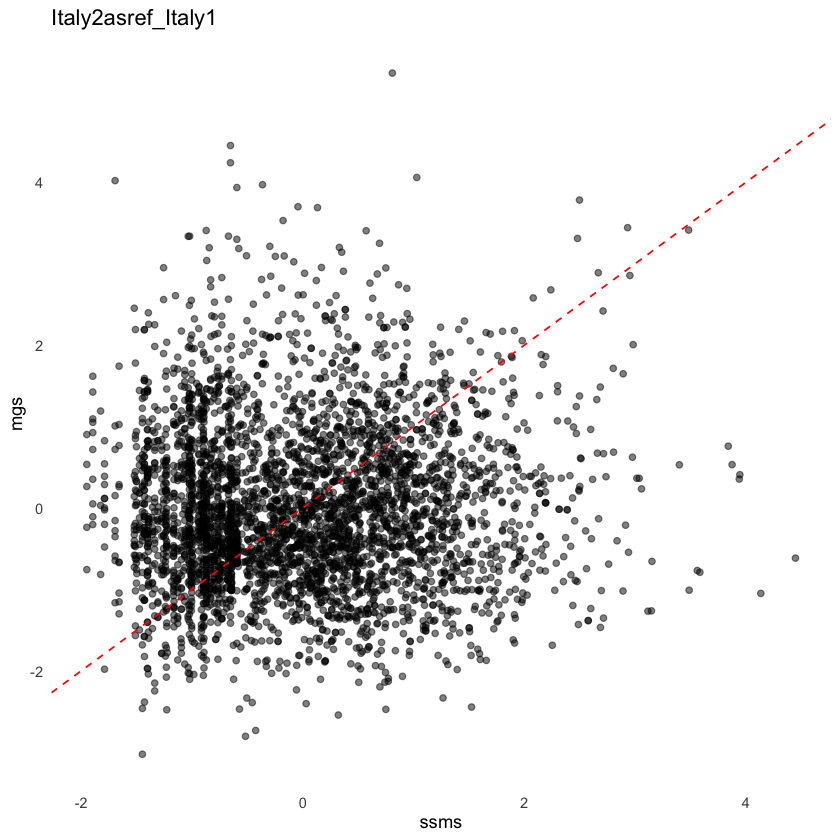

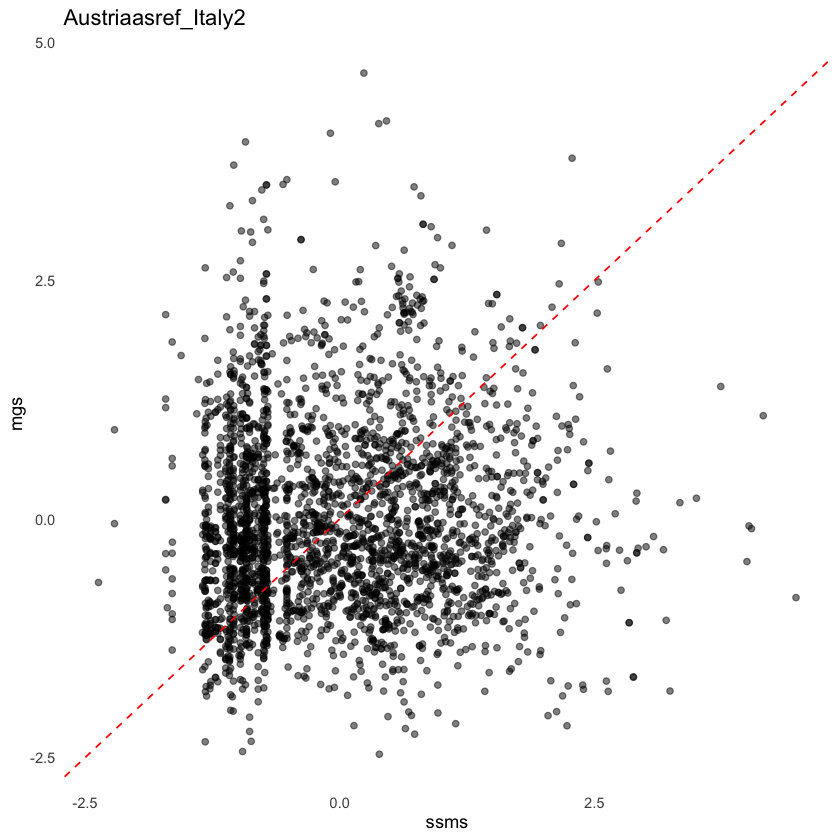

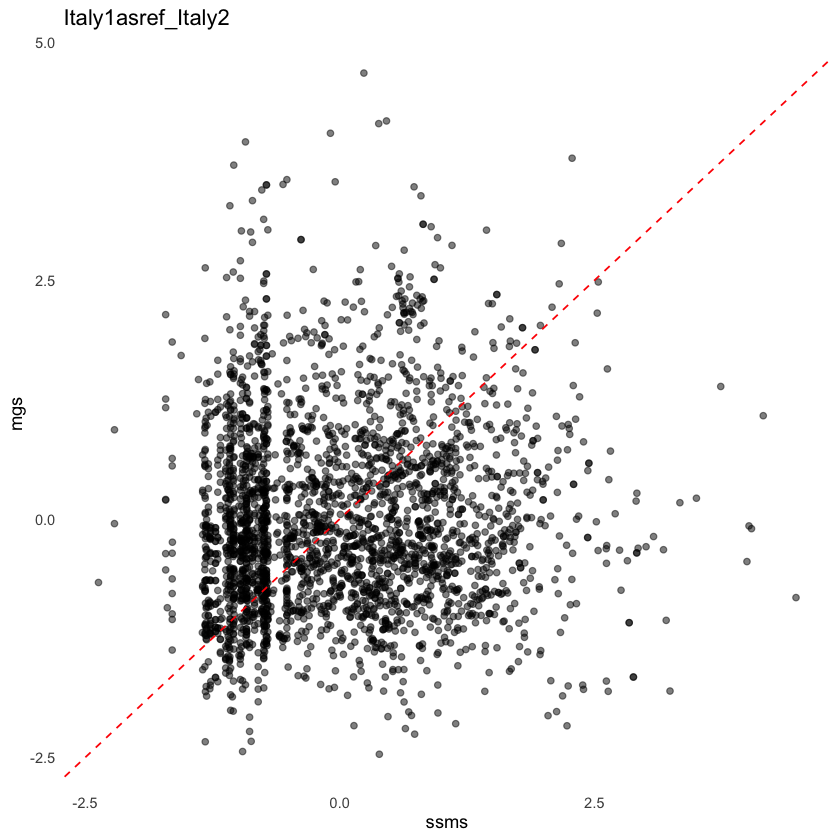

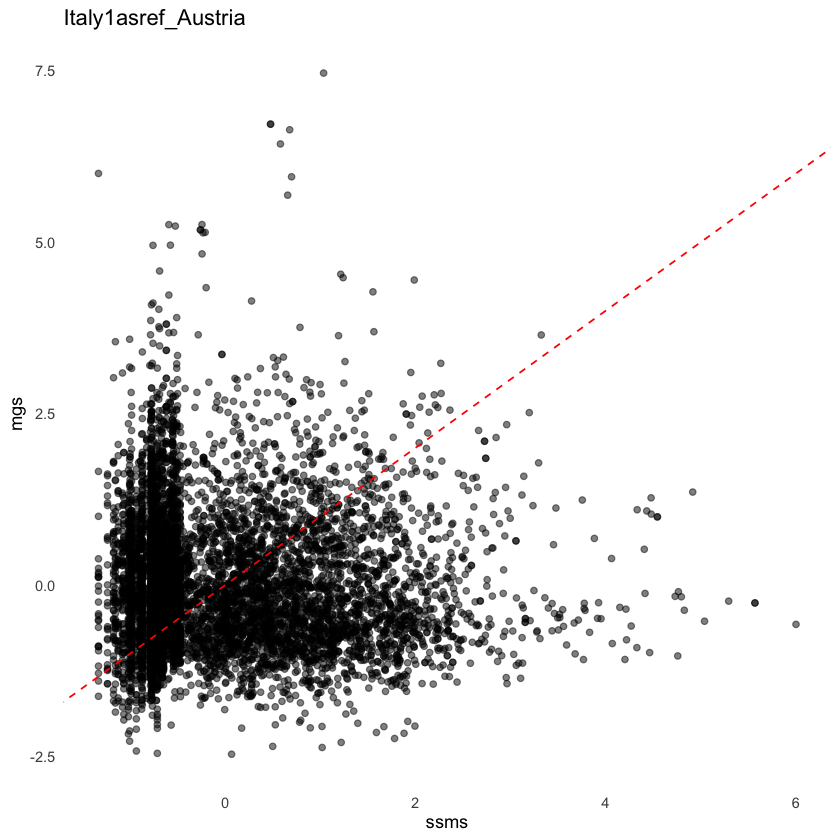

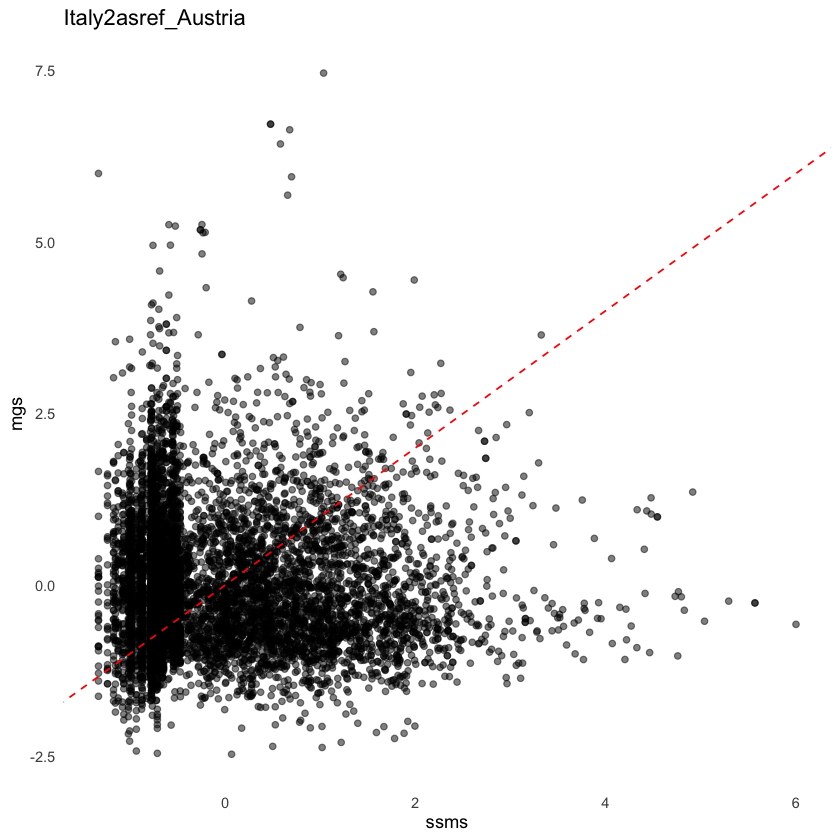

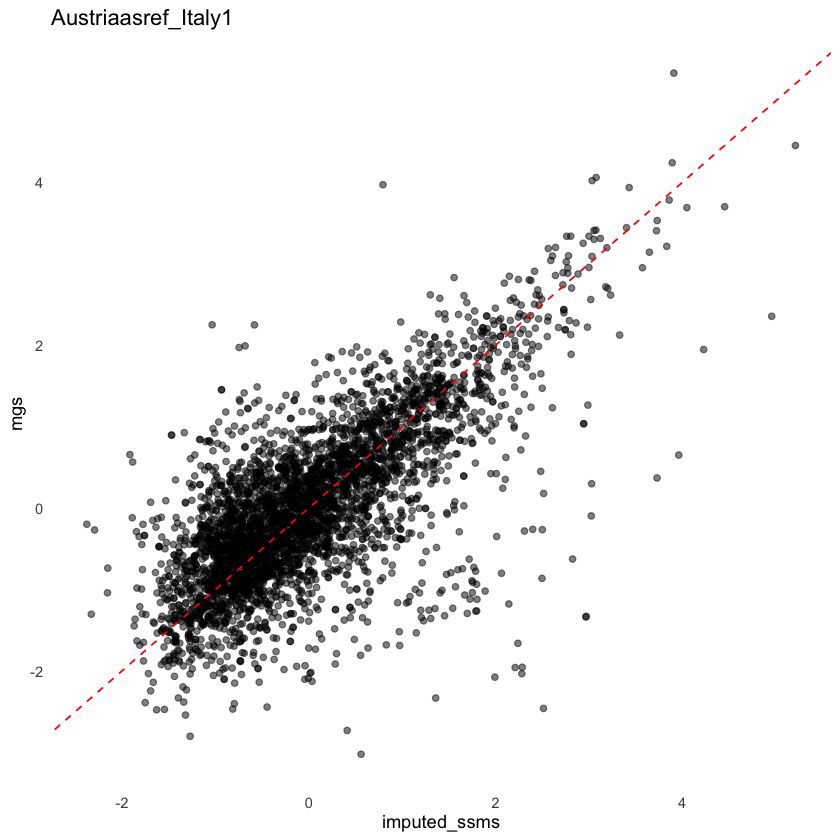

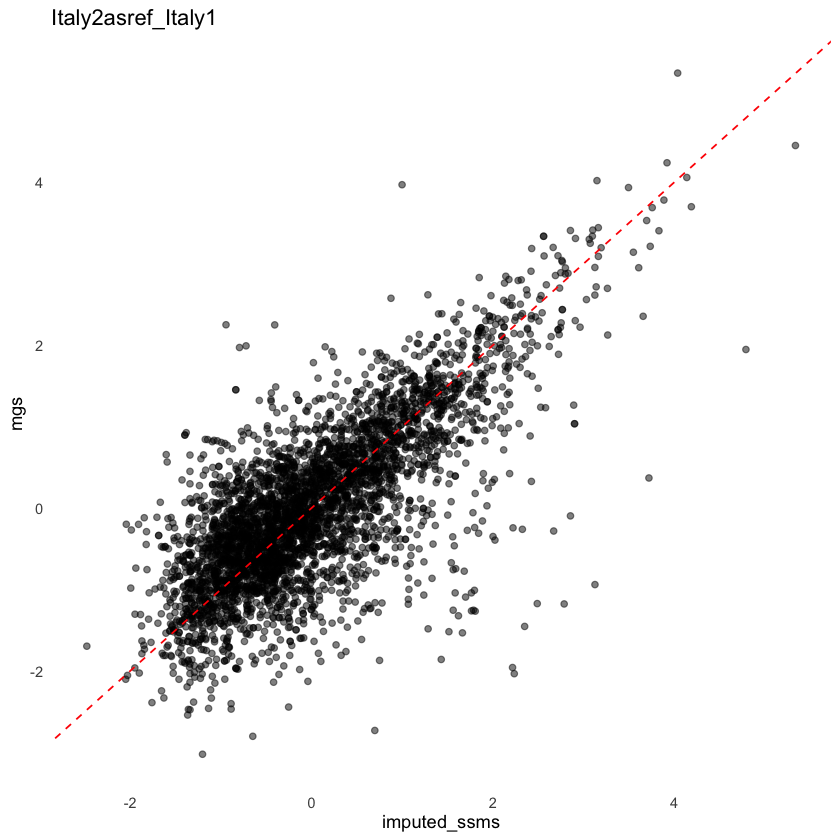

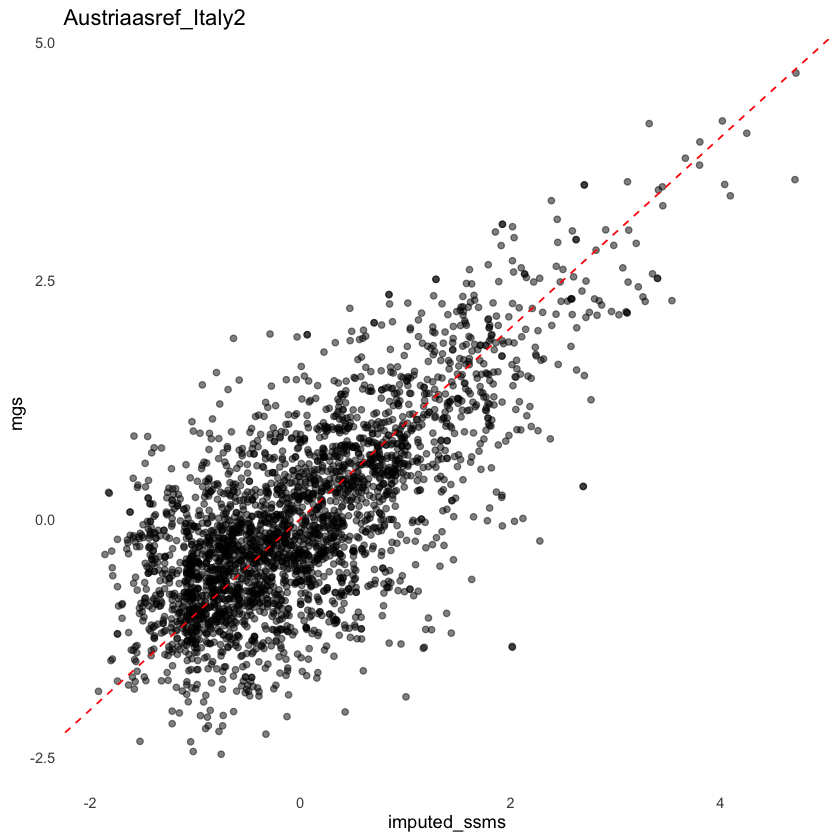

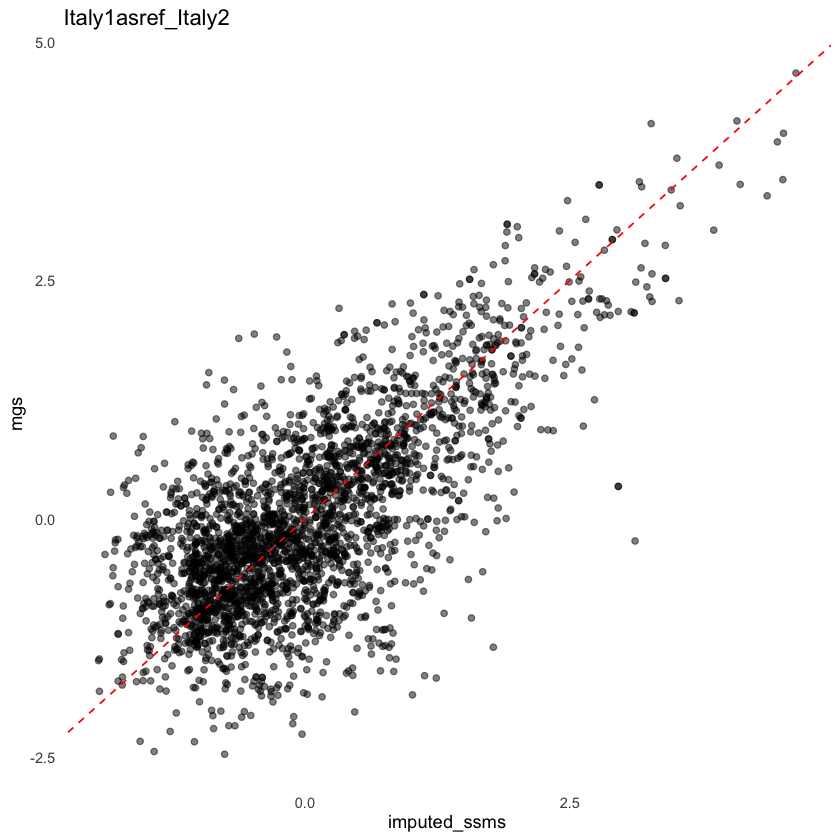

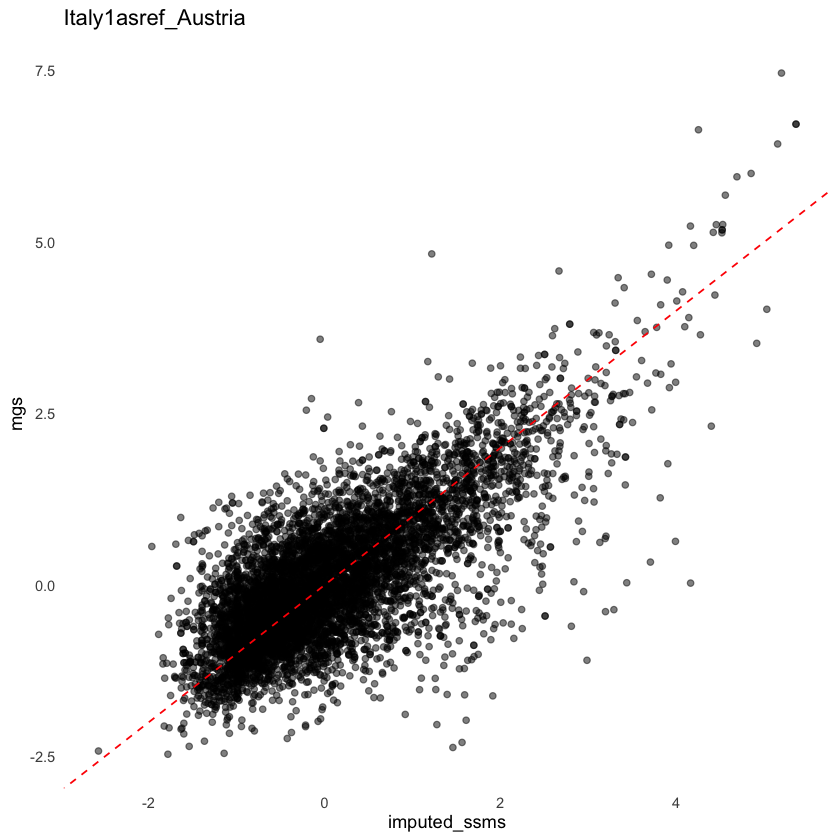

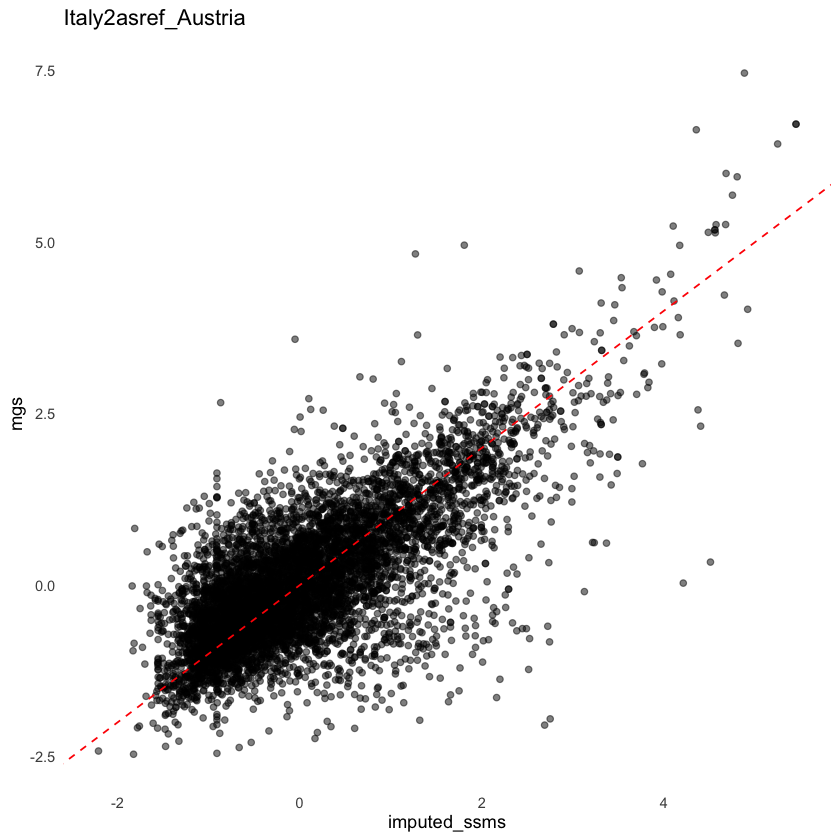

In [3]:
# z score
source("utilities.R")
library(ggplot2)
library(tidyr)

# compare different method -- among those imputed most frequently EC
Italy2_ssms_sorted <- dfs_aligned$Italy2_ssms_pw[order(rowSums(dfs_aligned$Italy2_ssms_pw), decreasing = TRUE), ]

Italy1_ssms_sorted <- dfs_aligned$Italy1_ssms_pw[order(rowSums(dfs_aligned$Italy1_ssms_pw), decreasing = TRUE), ]
 
Austria_ssms_sorted <- dfs_aligned$Austria_ssms_pw[order(rowSums(dfs_aligned$Austria_ssms_pw), decreasing = TRUE), ]

# sort by the original ssms abundance
Italy2_imputed_only_pw_1 <- rownames(Italy2_ssms_sorted[c(1:50),])
Italy2_imputed_only_pw_50 <- rownames(Italy2_ssms_sorted[c(50:100),])
Italy2_imputed_only_pw_100 <- rownames(Italy2_ssms_sorted[c(100:150),])

Italy1_imputed_only_pw_1 <- rownames(Italy1_ssms_sorted[c(1:50),])
Italy1_imputed_only_pw_50 <- rownames(Italy1_ssms_sorted[c(50:100),])
Italy1_imputed_only_pw_100 <- rownames(Italy1_ssms_sorted[c(100:150),])

Austria_imputed_only_pw_1 <- rownames(Austria_ssms_sorted[c(1:50),])
Austria_imputed_only_pw_50 <- rownames(Austria_ssms_sorted[c(50:100),])
Austria_imputed_only_pw_100 <- rownames(Austria_ssms_sorted[c(100:150),])

# visualize the z score of mgs, ssms, imputed ssms
str(dfs_aligned$Italy2_mgs_pw)
str(Italy2_imputed_only_pw_100)


Italy2_mgs_sub <- dfs_aligned$Italy2_mgs_pw[Italy2_imputed_only_pw_100, ]
Italy2_ssms_sub <- dfs_aligned$Italy2_ssms_pw[Italy2_imputed_only_pw_100, ]

Italy1_mgs_sub <- dfs_aligned$Italy1_mgs_pw[Italy1_imputed_only_pw_100, ]
Italy1_ssms_sub <- dfs_aligned$Italy1_ssms_pw[Italy1_imputed_only_pw_100, ]

Austria_mgs_sub <- dfs_aligned$Austria_mgs_pw[Austria_imputed_only_pw_100, ]
Austria_ssms_sub <- dfs_aligned$Austria_ssms_pw[Austria_imputed_only_pw_100, ]


predicted_pw_spiec_Austriaasref_Italy2_sub <- dfs_aligned$predicted_pw_spiec_Austriaasref_Italy2[Italy2_imputed_only_pw_100, ]
predicted_pw_spiec_Italy1asref_Italy2_sub <- dfs_aligned$predicted_pw_spiec_Italy1asref_Italy2[Italy2_imputed_only_pw_100, ]

predicted_pw_spiec_Austriaasref_Italy1_sub <- dfs_aligned$predicted_pw_spiec_Austriaasref_Italy1[Italy1_imputed_only_pw_100, ]
predicted_pw_spiec_Italy2asref_Italy1_sub <- dfs_aligned$predicted_pw_spiec_Italy2asref_Italy1[Italy1_imputed_only_pw_100, ] 

predicted_pw_spiec_Italy1asref_Austria_sub <- dfs_aligned$predicted_pw_spiec_Italy1asref_Austria[Austria_imputed_only_pw_100, ]
predicted_pw_spiec_Italy2asref_Austria_sub <- dfs_aligned$predicted_pw_spiec_Italy2asref_Austria[Austria_imputed_only_pw_100, ]


str(as.vector(t(scale(t(Italy2_mgs_sub)))))
str(as.vector(t(scale(t(Italy2_ssms_sub)))))
str(as.vector(t(scale(t(predicted_pw_spiec_Austriaasref_Italy2_sub)))))

# for Italy2
scarlet_z_socre_Austriaasref_Italy2 <- data.frame(
    "mgs" = as.vector(t(scale(t(Italy2_mgs_sub)))),
    "ssms" = as.vector(t(scale(t(Italy2_ssms_sub)))),
    "imputed_ssms" = as.vector(t(scale(t(predicted_pw_spiec_Austriaasref_Italy2_sub))))
)

scarlet_z_socre_Italy1asref_Italy2 <- data.frame(
    "mgs" = as.vector(t(scale(t(Italy2_mgs_sub)))),
    "ssms" = as.vector(t(scale(t(Italy2_ssms_sub)))),
    "imputed_ssms" = as.vector(t(scale(t(predicted_pw_spiec_Italy1asref_Italy2_sub))))
)
# for Italy1
scarlet_z_socre_Austriaasref_Italy1 <- data.frame(
    "mgs" = as.vector(t(scale(t(Italy1_mgs_sub)))),
    "ssms" = as.vector(t(scale(t(Italy1_ssms_sub)))),
    "imputed_ssms" = as.vector(t(scale(t(predicted_pw_spiec_Austriaasref_Italy1_sub))))
) 
scarlet_z_socre_Italy2asref_Italy1 <- data.frame(
    "mgs" = as.vector(t(scale(t(Italy1_mgs_sub)))),
    "ssms" = as.vector(t(scale(t(Italy1_ssms_sub)))),
    "imputed_ssms" = as.vector(t(scale(t(predicted_pw_spiec_Italy2asref_Italy1_sub))))
) 
# for Austria
scarlet_z_socre_Italy1asref_Austria <- data.frame(
    "mgs" = as.vector(t(scale(t(Austria_mgs_sub)))),
    "ssms" = as.vector(t(scale(t(Austria_ssms_sub)))),
    "imputed_ssms" = as.vector(t(scale(t(predicted_pw_spiec_Italy1asref_Austria_sub))))
)
scarlet_z_socre_Italy2asref_Austria <- data.frame(  
    "mgs" = as.vector(t(scale(t(Austria_mgs_sub)))),
    "ssms" = as.vector(t(scale(t(Austria_ssms_sub)))),
    "imputed_ssms" = as.vector(t(scale(t(predicted_pw_spiec_Italy2asref_Austria_sub))))
) 

# 
scarlet_z_socre_Austriaasref_Italy1_long <- pivot_longer(scarlet_z_socre_Austriaasref_Italy1, cols = c(ssms, imputed_ssms), 
                        names_to = "type", values_to = "x_value")

scarlet_z_socre_Italy2asref_Italy1_long <- pivot_longer(scarlet_z_socre_Italy2asref_Italy1, cols = c(ssms, imputed_ssms), 
                                                        names_to = "type", values_to = "x_value")

scarlet_z_socre_Austriaasref_Italy2_long <- pivot_longer(scarlet_z_socre_Austriaasref_Italy2, cols = c(ssms, imputed_ssms), 
                                                        names_to = "type", values_to = "x_value")

scarlet_z_socre_Italy1asref_Italy2_long <- pivot_longer(scarlet_z_socre_Italy1asref_Italy2, cols = c(ssms, imputed_ssms), 
                                                        names_to = "type", values_to = "x_value")

scarlet_z_socre_Italy1asref_Austria_long <- pivot_longer(scarlet_z_socre_Italy1asref_Austria, cols = c(ssms, imputed_ssms), 
                                                        names_to = "type", values_to = "x_value")

scarlet_z_socre_Italy2asref_Austria_long <- pivot_longer(scarlet_z_socre_Italy2asref_Austria, cols = c(ssms, imputed_ssms), 
                                                        names_to = "type", values_to = "x_value") 

ggplot(scarlet_z_socre_Austriaasref_Italy1_long, aes(x = x_value, y = mgs, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(16, 17)) +  
  theme_minimal() +
  theme(panel.grid = element_blank()) +
  labs(x = "SSMS (Original or Imputed)",
       y = "MGS",
       title = "Austriaasref_Italy1")

ggplot(scarlet_z_socre_Italy2asref_Italy1_long, aes(x = x_value, y = mgs, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(16, 17)) +  
  theme_minimal() +
  theme(panel.grid = element_blank()) +
  labs(x = "SSMS (Original or Imputed)",
       y = "MGS",
       title = "Italy2asref_Italy1")    
ggplot(scarlet_z_socre_Austriaasref_Italy2_long, aes(x = x_value, y = mgs, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(16, 17)) +  
  theme_minimal() +
  theme(panel.grid = element_blank()) +
  labs(x = "SSMS (Original or Imputed)",
       y = "MGS",
       title = "Austriaasref_Italy2")
ggplot(scarlet_z_socre_Italy1asref_Italy2_long, aes(x = x_value, y = mgs, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(16, 17)) +  
  theme_minimal() +
  theme(panel.grid = element_blank()) +
  labs(x = "SSMS (Original or Imputed)",
       y = "MGS",
       title = "Italy1asref_Italy2")
ggplot(scarlet_z_socre_Italy1asref_Austria_long, aes(x = x_value, y = mgs, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(16, 17)) +  
  theme_minimal() +
  theme(panel.grid = element_blank()) +
  labs(x = "SSMS (Original or Imputed)",
       y = "MGS",
       title = "Italy1asref_Austria")
ggplot(scarlet_z_socre_Italy2asref_Austria_long, aes(x = x_value, y = mgs, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(16, 17)) +  
  theme_minimal() +
  theme(panel.grid = element_blank()) +
  labs(x = "SSMS (Original or Imputed)",
       y = "MGS",
       title = "Italy2asref_Austria") 
### original ssms vs mgs  
ggplot(scarlet_z_socre_Austriaasref_Italy1, aes(x = ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "ssms",
       y = "mgs",
       title = "Austriaasref_Italy1") +
  theme_minimal() +
  theme(panel.grid = element_blank()) 
ggplot(scarlet_z_socre_Italy2asref_Italy1, aes(x = ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "ssms",
       y = "mgs",
       title = "Italy2asref_Italy1") +
  theme_minimal() +
  theme(panel.grid = element_blank())
ggplot(scarlet_z_socre_Austriaasref_Italy2, aes(x = ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "ssms",
       y = "mgs",
       title = "Austriaasref_Italy2") +
  theme_minimal() +
  theme(panel.grid = element_blank())
ggplot(scarlet_z_socre_Italy1asref_Italy2, aes(x = ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "ssms",
       y = "mgs",
       title = "Italy1asref_Italy2") +
  theme_minimal() +
  theme(panel.grid = element_blank())
ggplot(scarlet_z_socre_Italy1asref_Austria, aes(x = ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "ssms",    
       y = "mgs",
       title = "Italy1asref_Austria") +
  theme_minimal() +
  theme(panel.grid = element_blank())
ggplot(scarlet_z_socre_Italy2asref_Austria, aes(x = ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype =  "dashed", color = "red") +
  labs(x = "ssms",
       y = "mgs",
       title = "Italy2asref_Austria") +
  theme_minimal() +
  theme(panel.grid = element_blank()) 

  
### imputed ssms vs mgs
ggplot(scarlet_z_socre_Austriaasref_Italy1, aes(x = imputed_ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "imputed_ssms",
       y = "mgs",
       title = "Austriaasref_Italy1") +
  theme_minimal() +
  theme(panel.grid = element_blank())
ggplot(scarlet_z_socre_Italy2asref_Italy1, aes(x = imputed_ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "imputed_ssms",
       y = "mgs",
       title = "Italy2asref_Italy1") +
  theme_minimal() +
  theme(panel.grid = element_blank())  
ggplot(scarlet_z_socre_Austriaasref_Italy2, aes(x = imputed_ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "imputed_ssms",
       y = "mgs",
       title = "Austriaasref_Italy2") +
  theme_minimal() +
  theme(panel.grid = element_blank())
ggplot(scarlet_z_socre_Italy1asref_Italy2, aes(x = imputed_ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype =  "dashed", color = "red") +
  labs(x = "imputed_ssms",
       y = "mgs",
       title = "Italy1asref_Italy2") +
  theme_minimal() +
  theme(panel.grid = element_blank())   
ggplot(scarlet_z_socre_Italy1asref_Austria, aes(x = imputed_ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "imputed_ssms",
       y = "mgs",
       title = "Italy1asref_Austria") +
  theme_minimal() +
  theme(panel.grid = element_blank())   
ggplot(scarlet_z_socre_Italy2asref_Austria, aes(x = imputed_ssms, y = mgs)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(x = "imputed_ssms",
       y = "mgs",
       title = "Italy2asref_Austria") +
  theme_minimal() +
  theme(panel.grid = element_blank()) 

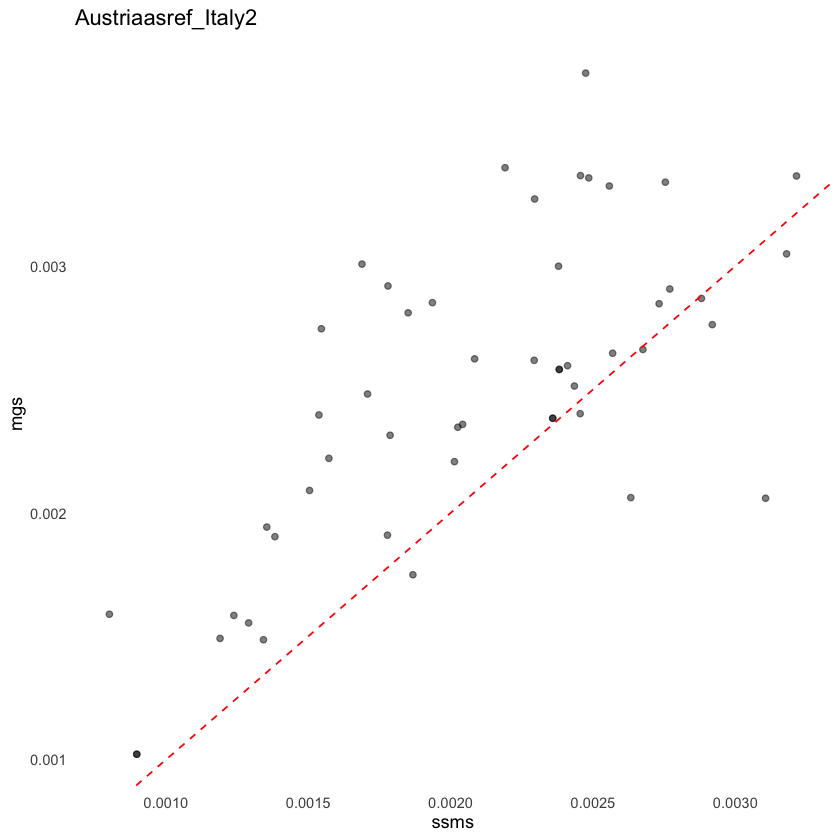

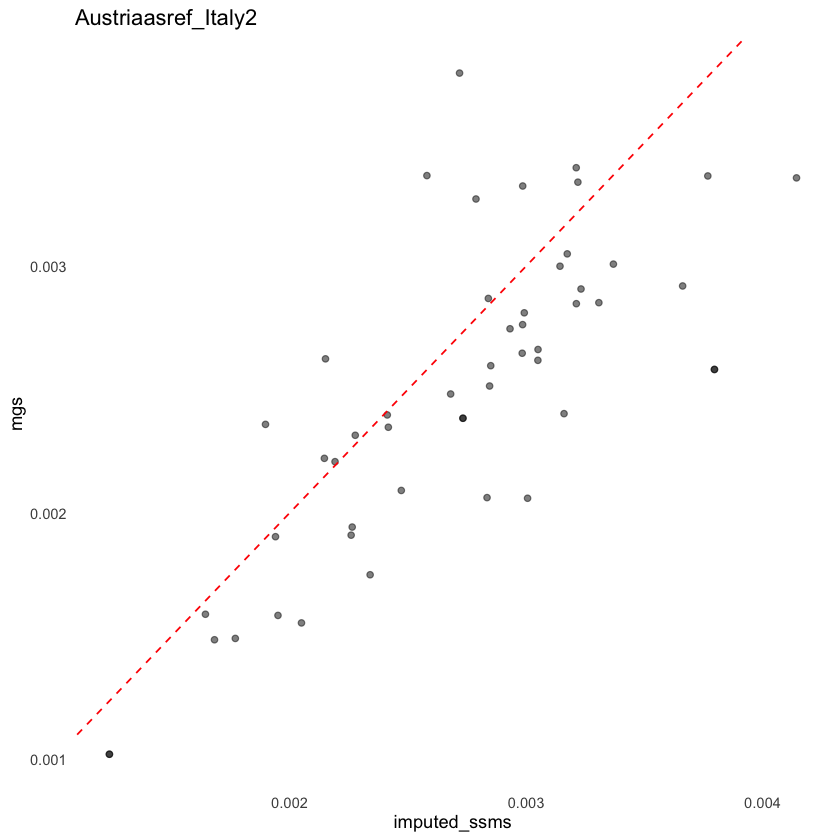

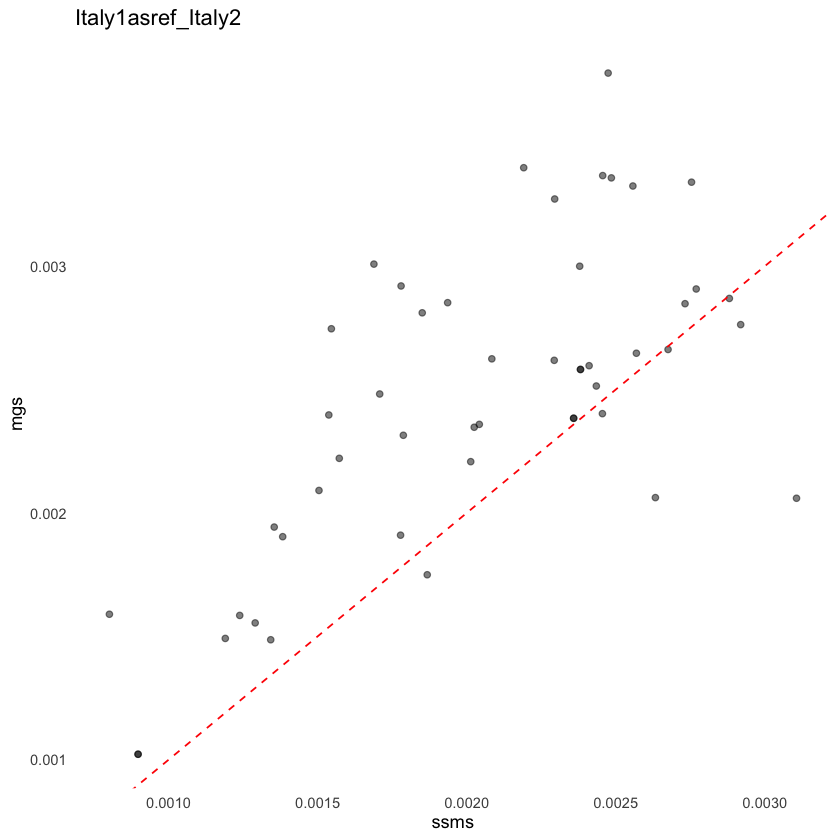

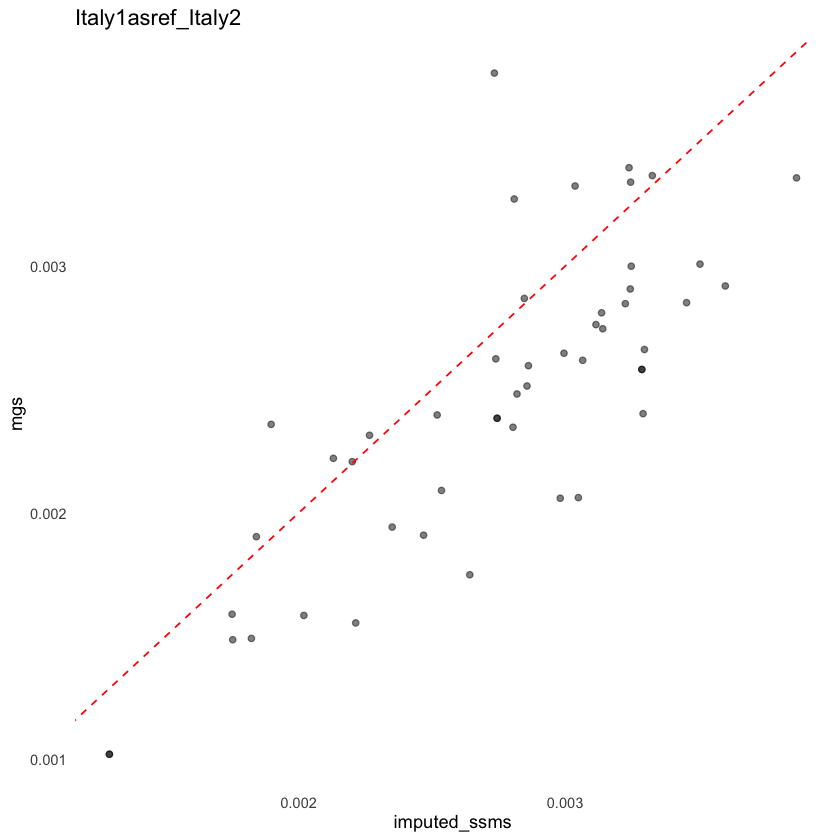

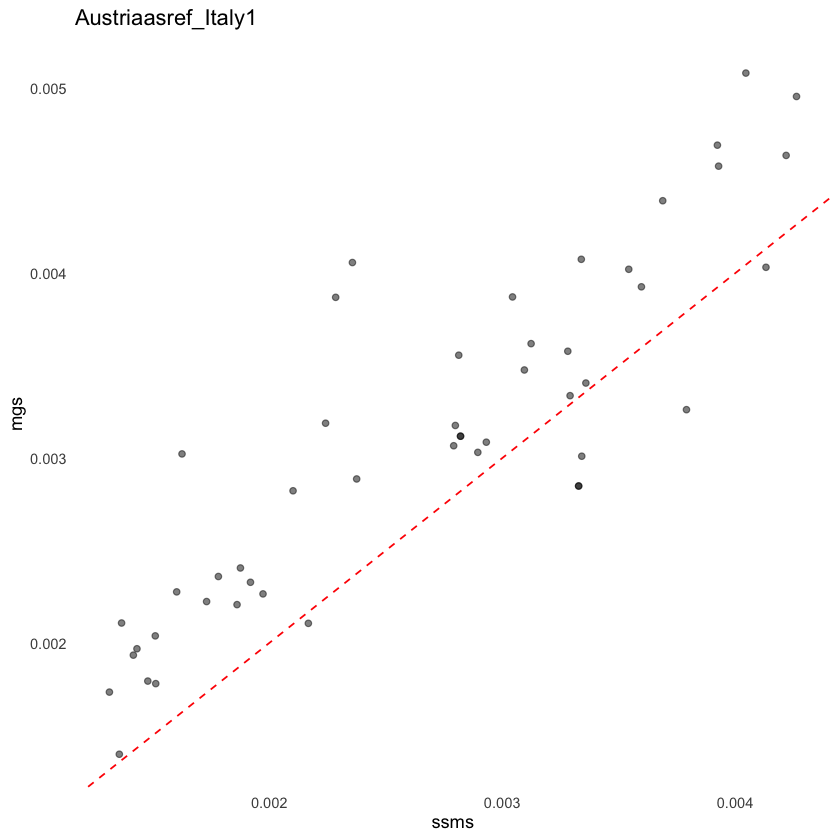

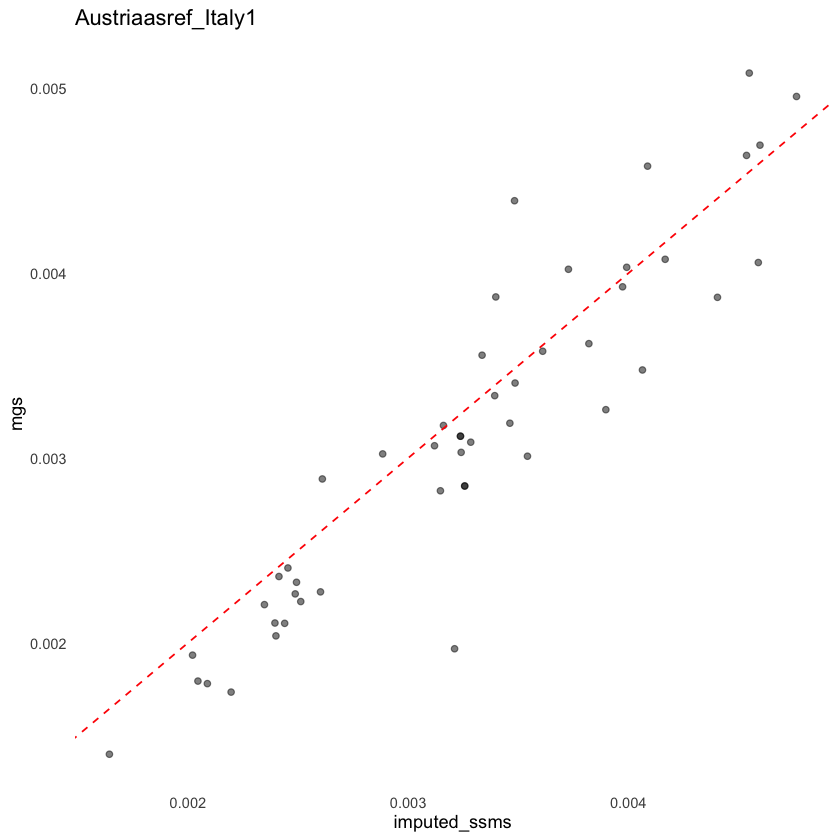

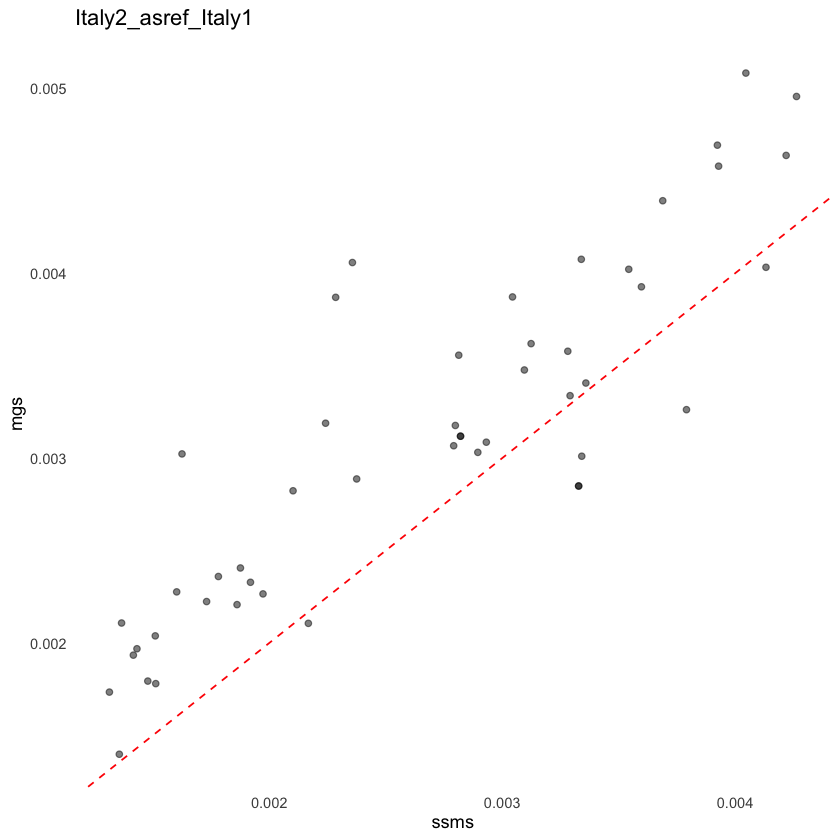

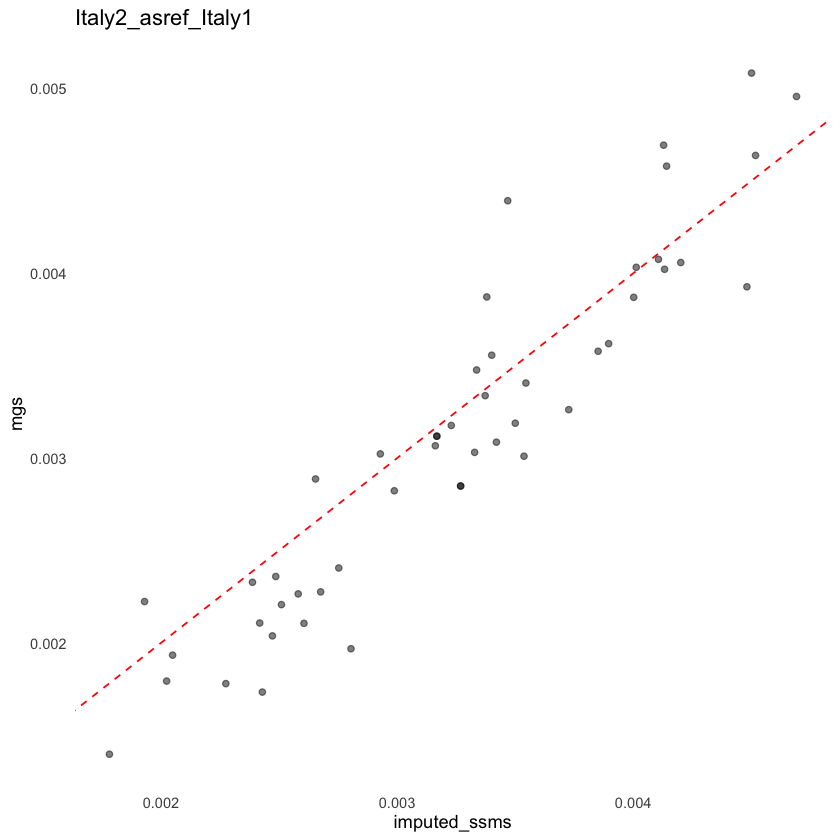

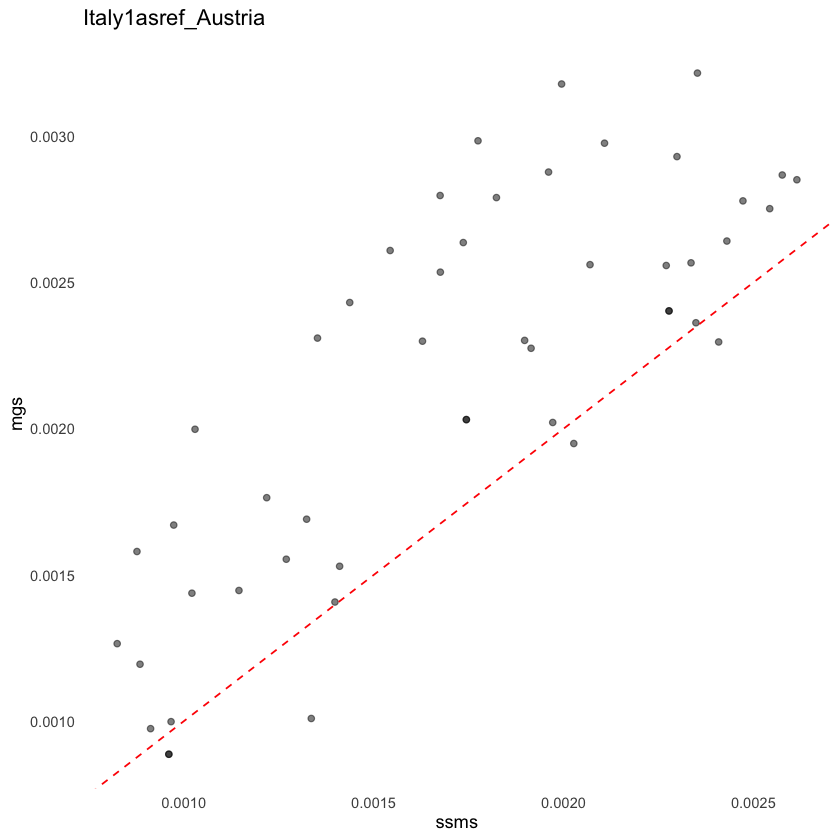

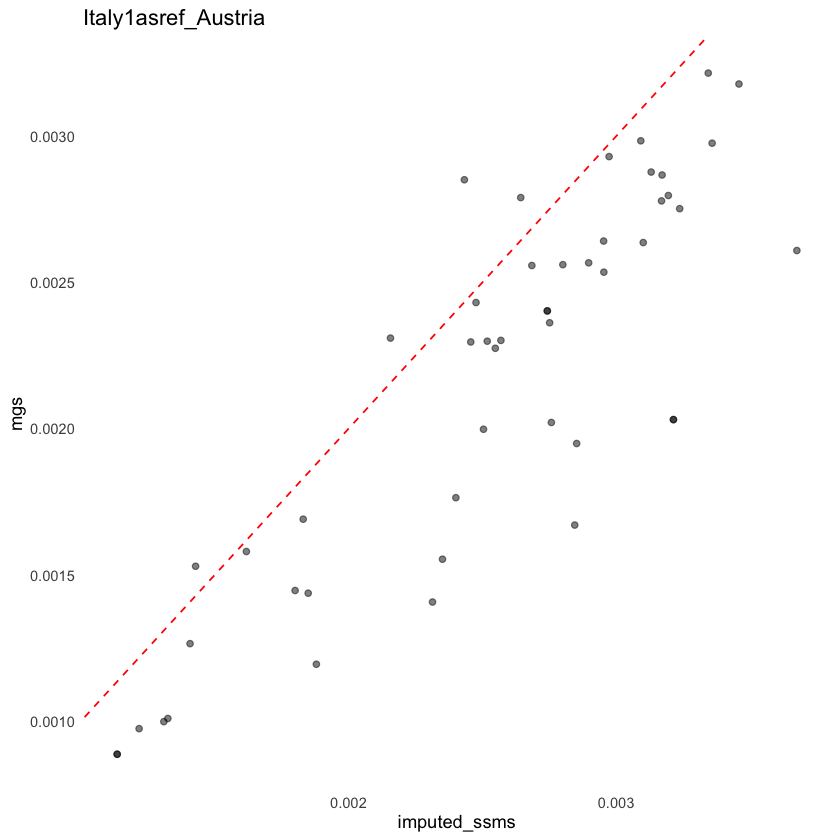

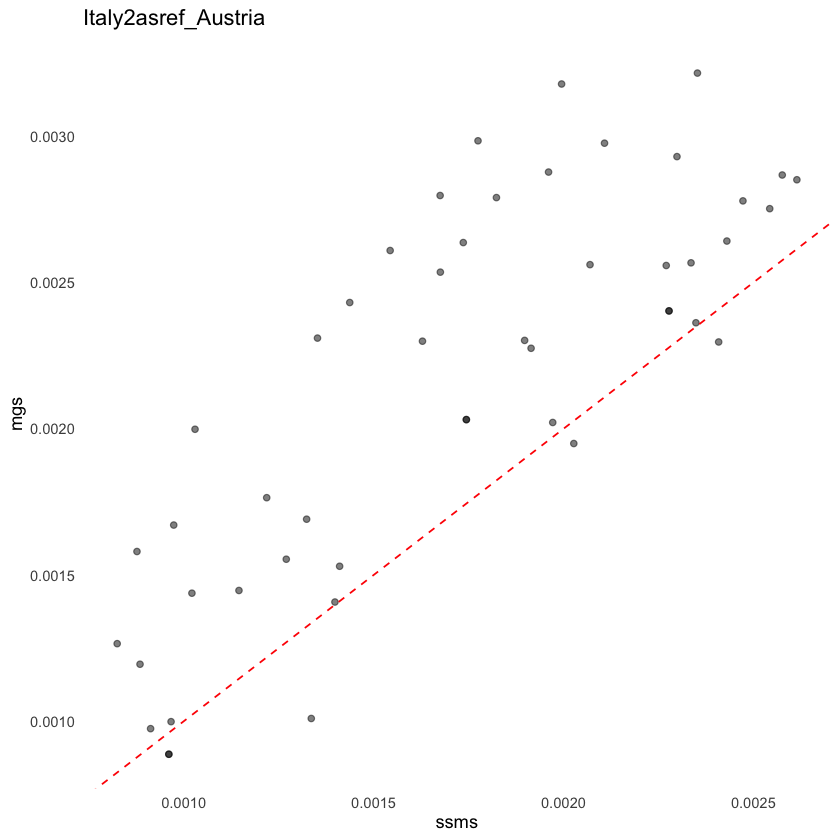

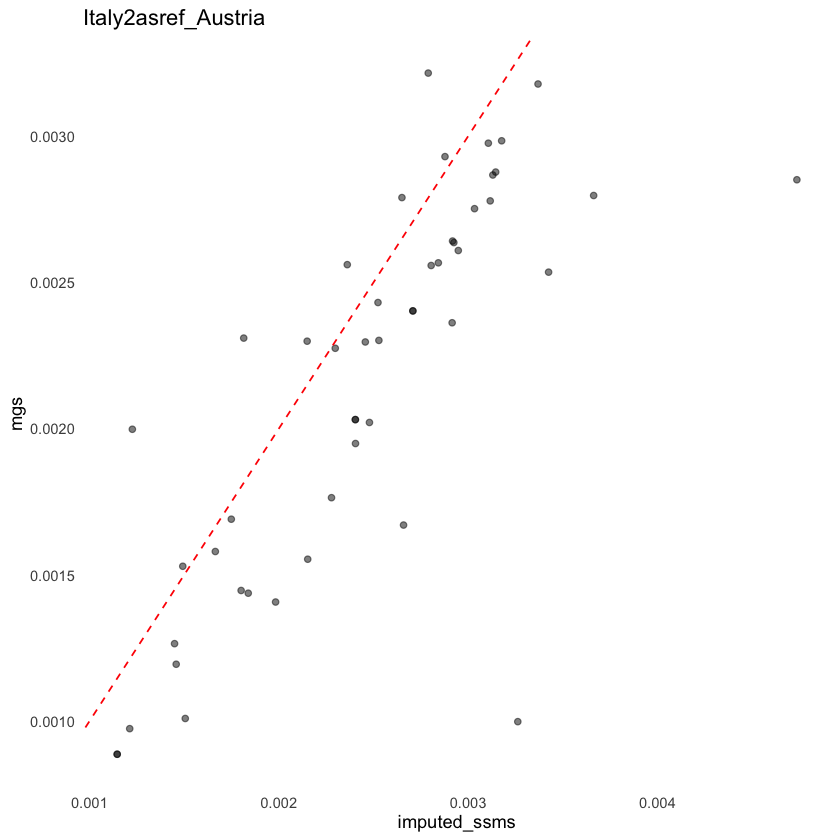

In [6]:
# abundance
source("utilities.R")
library(ggplot2)
library(tidyr)

# compare different method -- among those imputed most frequently EC
Italy2_ssms_sorted <- Italy2_ssms_pw[order(rowSums(Italy2_ssms_pw), decreasing = TRUE), ]

Italy1_ssms_sorted <- Italy1_ssms_pw[order(rowSums(Italy1_ssms_pw), decreasing = TRUE), ]

Austria_ssms_sorted <- Austria_ssms_pw[order(rowSums(Austria_ssms_pw), decreasing = TRUE), ]

# sort by the original ssms abundance

# visualize the z score of mgs, ssms, imputed ssms
Italy2_mgs_sub <- Italy2_mgs_pw[Italy2_imputed_only_pw_100, ]
Italy2_ssms_sub <- Italy2_ssms_pw[Italy2_imputed_only_pw_100, ]

Italy1_mgs_sub <- Italy1_mgs_pw[Italy1_imputed_only_pw_100, ]
Italy1_ssms_sub <- Italy1_ssms_pw[Italy1_imputed_only_pw_100, ]

Austria_mgs_sub <- Austria_mgs_pw[Austria_imputed_only_pw_100, ]
Austria_ssms_sub <- Austria_ssms_pw[Austria_imputed_only_pw_100, ]


predicted_pw_spiec_Austriaasref_Italy2_sub <- predicted_pw_spiec_Austriaasref_Italy2[Italy2_imputed_only_pw_100, ]
predicted_pw_spiec_Italy1asref_Italy2_sub <- predicted_pw_spiec_Italy1asref_Italy2[Italy2_imputed_only_pw_100, ]

predicted_pw_spiec_Austriaasref_Italy1_sub <- predicted_pw_spiec_Austriaasref_Italy1[Italy1_imputed_only_pw_100, ]
predicted_pw_spiec_Italy2asref_Italy1_sub <- predicted_pw_spiec_Italy2asref_Italy1[Italy1_imputed_only_pw_100, ] 

predicted_pw_spiec_Italy1asref_Austria_sub <- predicted_pw_spiec_Italy1asref_Austria[Austria_imputed_only_pw_100, ]
predicted_pw_spiec_Italy2asref_Austria_sub <- predicted_pw_spiec_Italy2asref_Austria[Austria_imputed_only_pw_100, ]

# for Italy2
scarlet_abundance_Austriaasref_Italy2 <- data.frame(
  "mgs" = as.vector(apply(Italy2_mgs_sub,1,mean)),
  "ssms" = as.vector(apply(Italy2_ssms_sub,1,mean)),
  "imputed_ssms" = as.vector(apply(predicted_pw_spiec_Austriaasref_Italy2_sub,1,mean))
)

scarlet_abundance_Italy1asref_Italy2 <- data.frame(
  "mgs" = as.vector(apply(Italy2_mgs_sub,1,mean)),
  "ssms" = as.vector(apply(Italy2_ssms_sub,1,mean)),
  "imputed_ssms" = as.vector(apply(predicted_pw_spiec_Italy1asref_Italy2_sub,1,mean))
)
# for Italy1
scarlet_abundance_Austriaasref_Italy1 <- data.frame(
  "mgs" = as.vector(apply(Italy1_mgs_sub,1,mean)),
  "ssms" = as.vector(apply(Italy1_ssms_sub,1,mean)),
  "imputed_ssms" = as.vector(apply(predicted_pw_spiec_Austriaasref_Italy1_sub,1,mean))
) 
scarlet_abundance_Italy2asref_Italy1 <- data.frame(
  "mgs" = as.vector(apply(Italy1_mgs_sub,1,mean)),
  "ssms" = as.vector(apply(Italy1_ssms_sub,1,mean)),
  "imputed_ssms" = as.vector(apply(predicted_pw_spiec_Italy2asref_Italy1_sub,1,mean))
) 
# for Austria
scarlet_abundance_Italy1asref_Austria <- data.frame(
  "mgs" = as.vector(apply(Austria_mgs_sub,1,mean)),
  "ssms" = as.vector(apply(Austria_ssms_sub,1,mean)),
  "imputed_ssms" = as.vector(apply(predicted_pw_spiec_Italy1asref_Austria_sub,1,mean))
)
scarlet_abundance_Italy2asref_Austria <- data.frame(  
  "mgs" = as.vector(apply(Austria_mgs_sub,1,mean)),
  "ssms" = as.vector(apply(Austria_ssms_sub,1,mean)),
  "imputed_ssms" = as.vector(apply(predicted_pw_spiec_Italy2asref_Austria_sub,1,mean))
)    


# plot original ssms vs mgs
scarlet_plot(scarlet_abundance_Austriaasref_Italy2, "ssms", "mgs", "Austriaasref_Italy2")
scarlet_plot(scarlet_abundance_Austriaasref_Italy2, "imputed_ssms", "mgs", "Austriaasref_Italy2")
scarlet_plot(scarlet_abundance_Italy1asref_Italy2[-c(1,2),], "ssms", "mgs", "Italy1asref_Italy2")
scarlet_plot(scarlet_abundance_Italy1asref_Italy2[-c(1,2),], "imputed_ssms", "mgs", "Italy1asref_Italy2")

scarlet_plot(scarlet_abundance_Austriaasref_Italy1[-c(1,2),], "ssms", "mgs", "Austriaasref_Italy1")
scarlet_plot(scarlet_abundance_Austriaasref_Italy1[-c(1,2),], "imputed_ssms", "mgs", "Austriaasref_Italy1")
scarlet_plot(scarlet_abundance_Italy2asref_Italy1[-c(1,2),], "ssms", "mgs", "Italy2_asref_Italy1")
scarlet_plot(scarlet_abundance_Italy2asref_Italy1[-c(1,2),], "imputed_ssms", "mgs", "Italy2_asref_Italy1")

scarlet_plot(scarlet_abundance_Italy1asref_Austria[-c(1,2),], "ssms", "mgs", "Italy1asref_Austria")
scarlet_plot(scarlet_abundance_Italy1asref_Austria[-c(1,2),], "imputed_ssms", "mgs", "Italy1asref_Austria")
scarlet_plot(scarlet_abundance_Italy2asref_Austria[-c(1,2),], "ssms", "mgs", "Italy2asref_Austria")
scarlet_plot(scarlet_abundance_Italy2asref_Austria[-c(1,2),], "imputed_ssms", "mgs", "Italy2asref_Austria") 

Warning message:
"Removed 535 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 485 rows containing missing values or values outside the scale range
(`geom_point()`)."


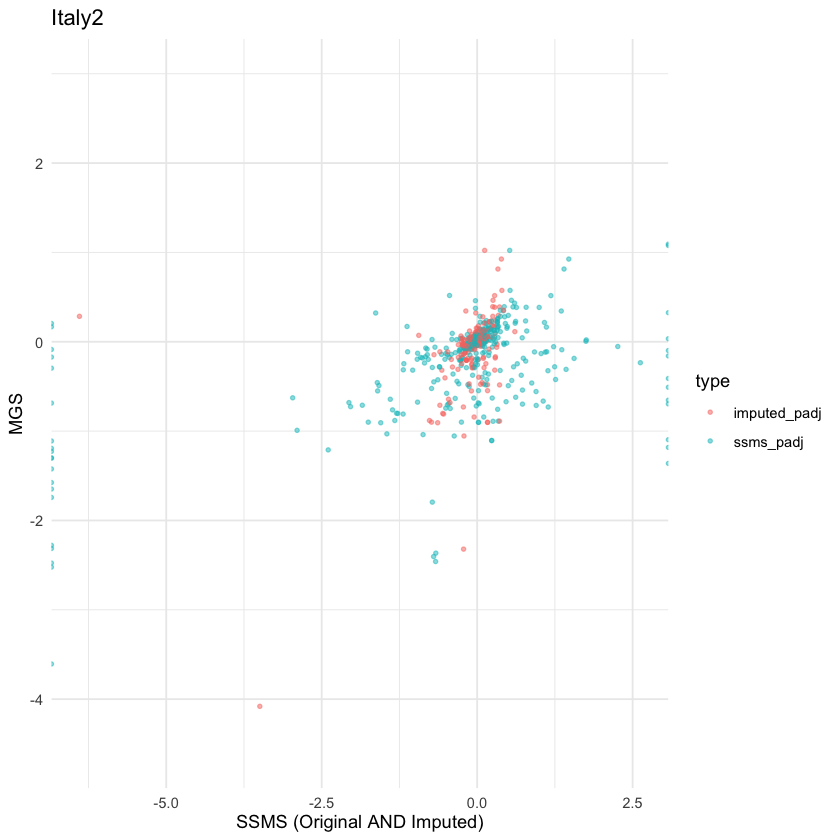

Warning message:
"Removed 486 rows containing missing values or values outside the scale range
(`geom_point()`)."


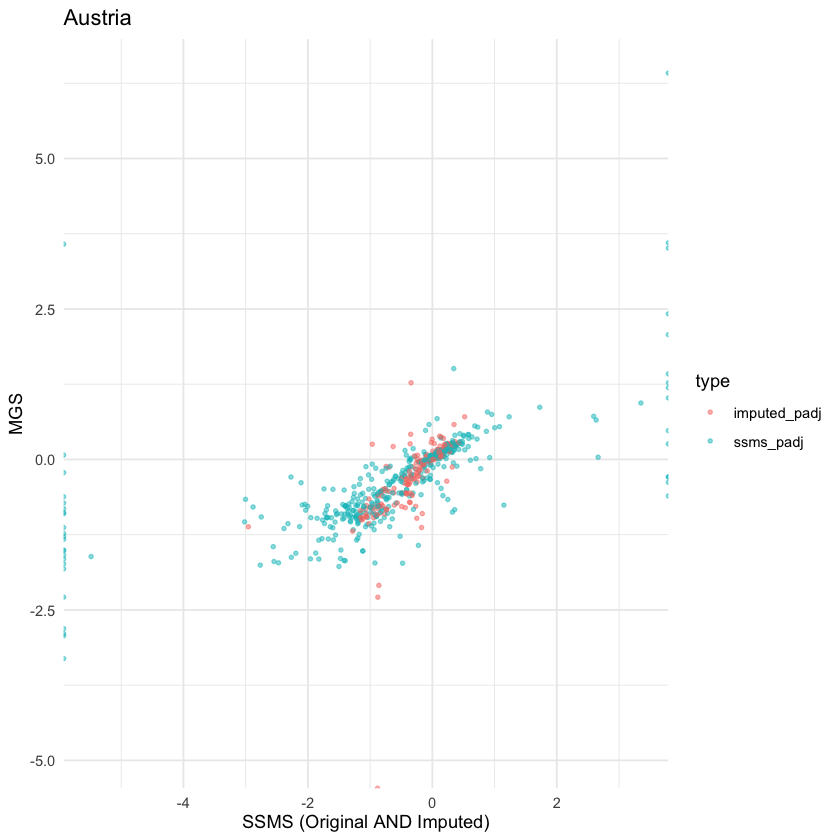

Warning message:
"Removed 496 rows containing missing values or values outside the scale range
(`geom_point()`)."


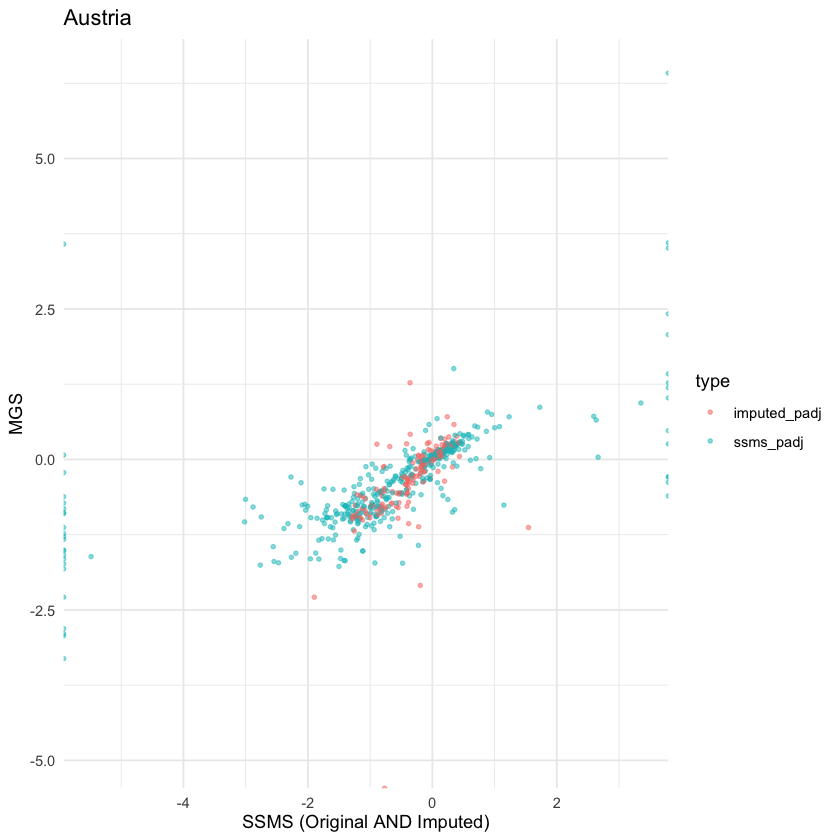

Warning message:
"Removed 497 rows containing missing values or values outside the scale range
(`geom_point()`)."


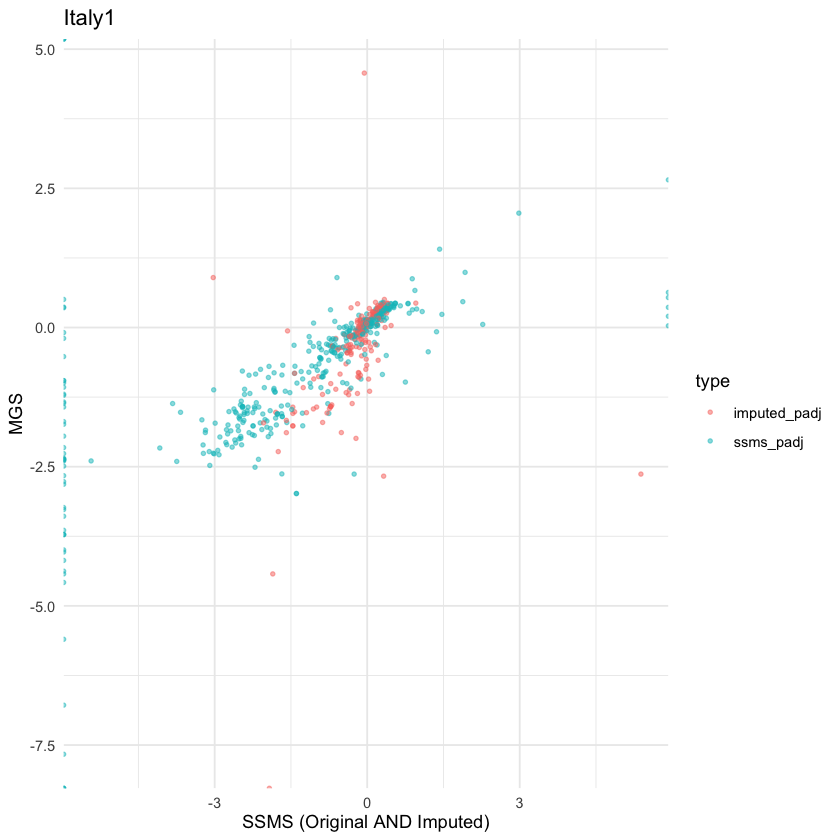

Warning message:
"Removed 536 rows containing missing values or values outside the scale range
(`geom_point()`)."


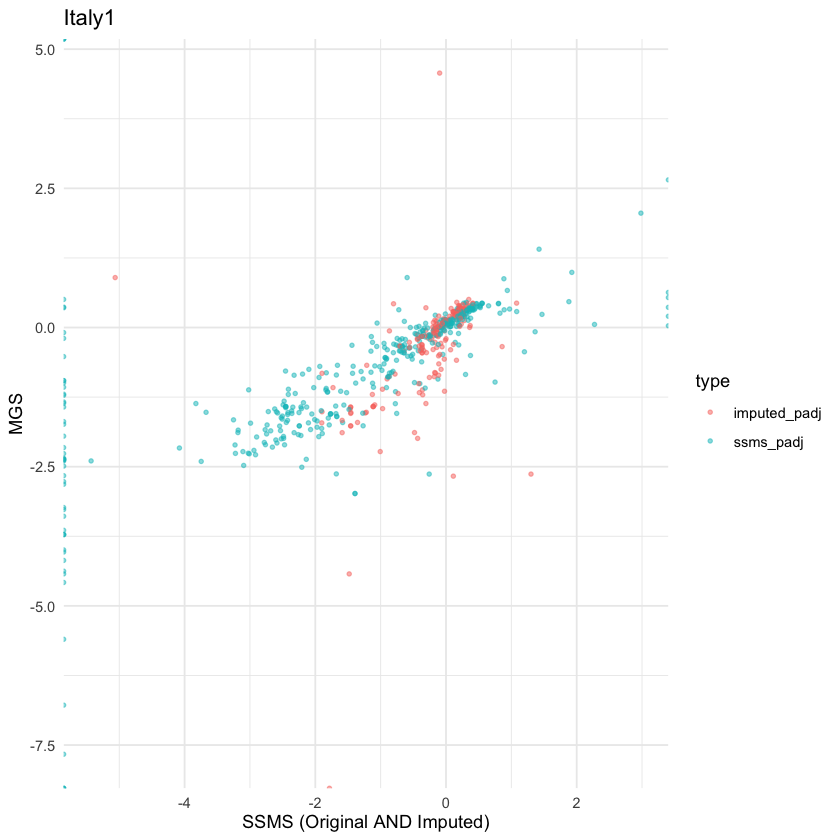

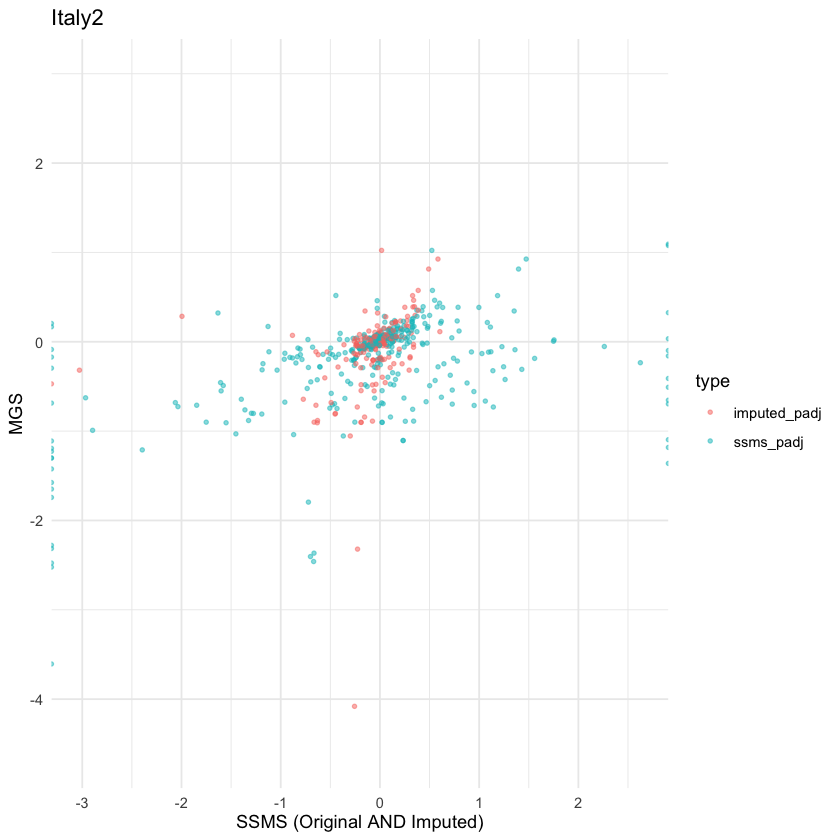

In [ ]:
source("utilities.R")
library(tidyr)
library(ggplot2)
fc_pw_Italy1asref_Italy2 <- calculate_fc(metadata = Italy2_metadata,
  mgs_matrix = dfs_aligned$Italy2_mgs_pw,
  shallow_matrix = dfs_aligned$Italy2_ssms_pw,
  imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy1asref_Italy2,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

fc_pw_Austriaasref_Italy2 <- calculate_fc(
  metadata = Italy2_metadata,
  mgs_matrix = dfs_aligned$Italy2_mgs_pw,
  shallow_matrix = dfs_aligned$Italy2_ssms_pw,
  imputed_matrix = dfs_aligned$predicted_pw_spiec_Austriaasref_Italy2,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

fc_pw_Italy2asref_Italy1 <- calculate_fc(metadata = Italy1_metadata,
  mgs_matrix = dfs_aligned$Italy1_mgs_pw,
  shallow_matrix = dfs_aligned$Italy1_ssms_pw,
  imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy2asref_Italy1,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

fc_pw_Austriaasref_Italy1 <- calculate_fc(metadata = Italy1_metadata,
  mgs_matrix = dfs_aligned$Italy1_mgs_pw,
  shallow_matrix = dfs_aligned$Italy1_ssms_pw,
  imputed_matrix = dfs_aligned$predicted_pw_spiec_Austriaasref_Italy1,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

fc_pw_Italy1asref_Austria <- calculate_fc(metadata = Austria_metadata,
  mgs_matrix = dfs_aligned$Austria_mgs_pw,
  shallow_matrix = dfs_aligned$Austria_ssms_pw,
  imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy1asref_Austria,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "NCBI_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

fc_pw_Italy2asref_Austria <- calculate_fc(metadata = Austria_metadata,
  mgs_matrix = dfs_aligned$Austria_mgs_pw,
  shallow_matrix = dfs_aligned$Austria_ssms_pw,
  imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy2asref_Austria,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "NCBI_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

fc_pw_Italy1asref_Italy2_long <- pivot_longer(fc_pw_Italy1asref_Italy2, cols = c(ssms_padj, imputed_padj), 
                        names_to = "type", values_to = "x_value")
fc_pw_Italy1asref_Austria_long <- pivot_longer(fc_pw_Italy1asref_Austria, cols = c(ssms_padj, imputed_padj), 
                        names_to = "type", values_to = "x_value")                      
fc_pw_Italy2asref_Austria_long <- pivot_longer(fc_pw_Italy2asref_Austria, cols = c(ssms_padj, imputed_padj), 
                        names_to = "type", values_to = "x_value")
fc_pw_Italy2asref_Italy1_long <- pivot_longer(fc_pw_Italy2asref_Italy1, cols = c(ssms_padj, imputed_padj), 
                        names_to = "type", values_to = "x_value")                      
fc_pw_Austriaasref_Italy2_long <- pivot_longer(fc_pw_Austriaasref_Italy2, cols = c(ssms_padj, imputed_padj), 
                        names_to = "type", values_to = "x_value")
fc_pw_Austriaasref_Italy1_long <- pivot_longer(fc_pw_Austriaasref_Italy1, cols = c(ssms_padj, imputed_padj), 
                        names_to = "type", values_to = "x_value")                      


ggplot(fc_pw_Italy1asref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")

ggplot(fc_pw_Italy1asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(fc_pw_Italy2asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(fc_pw_Italy2asref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(fc_pw_Austriaasref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(fc_pw_Austriaasref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")



Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warnin

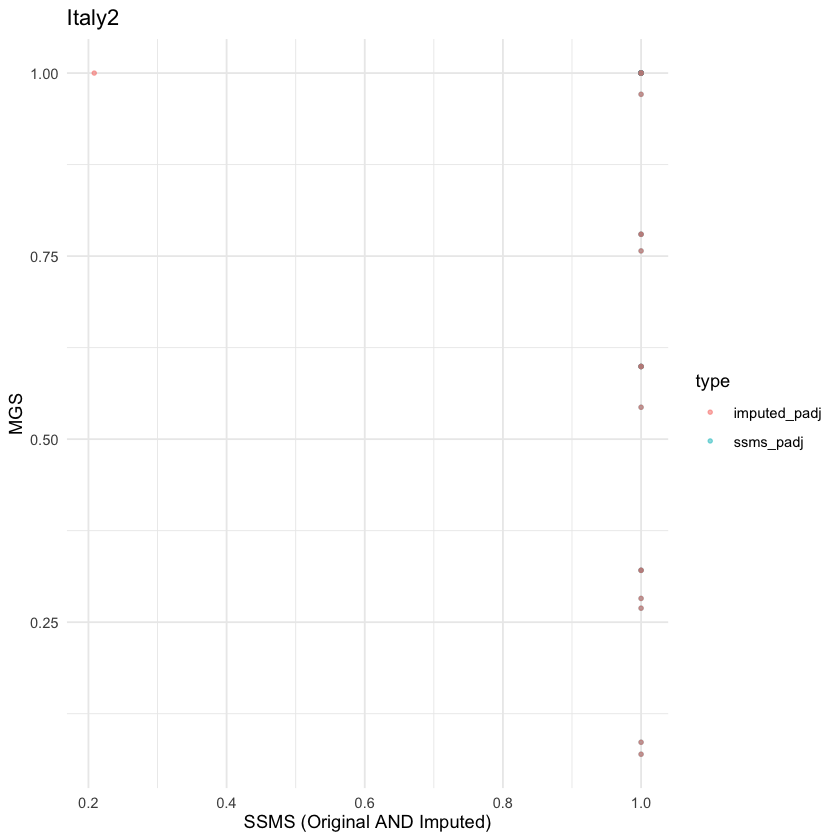

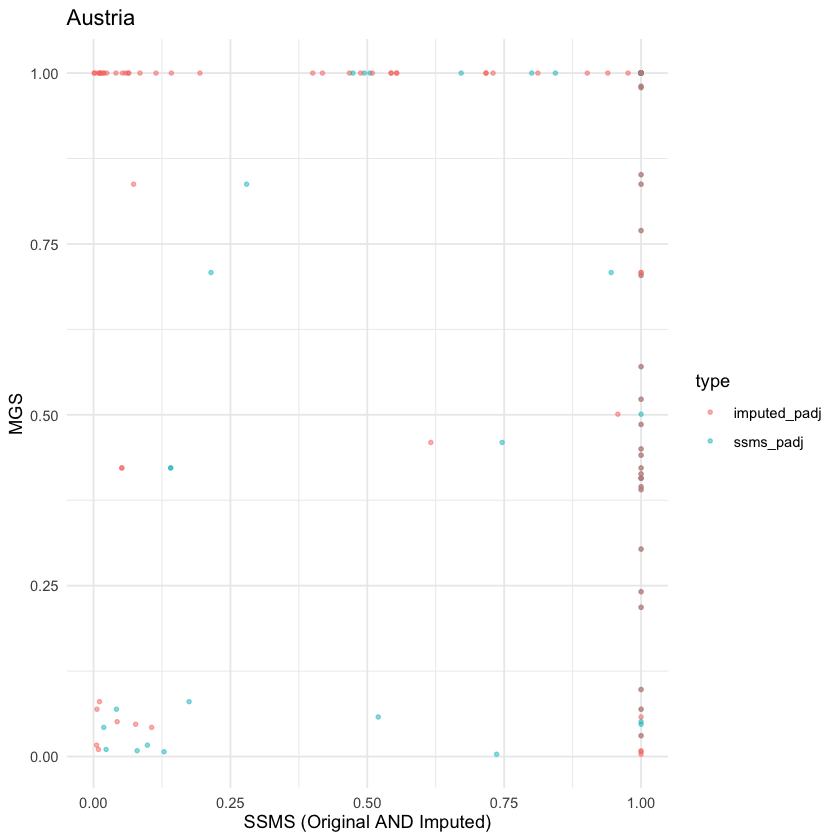

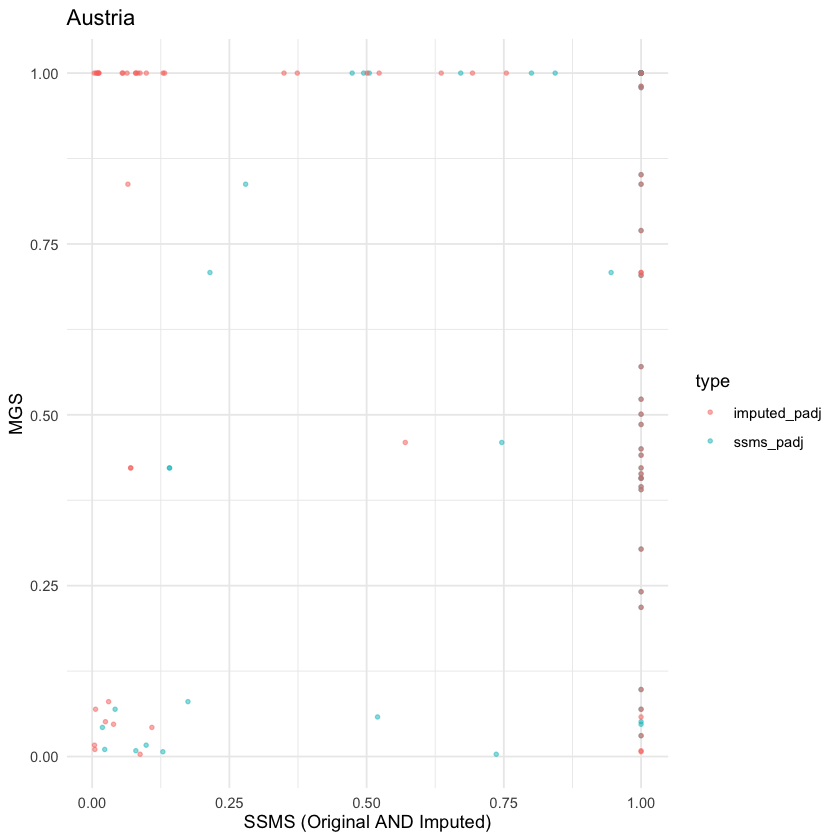

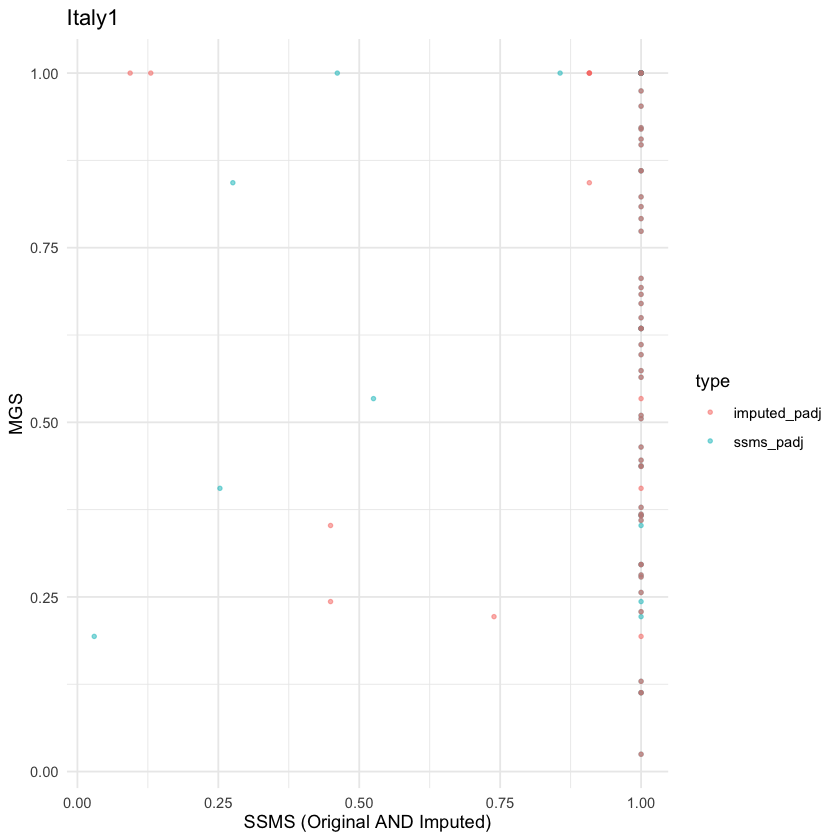

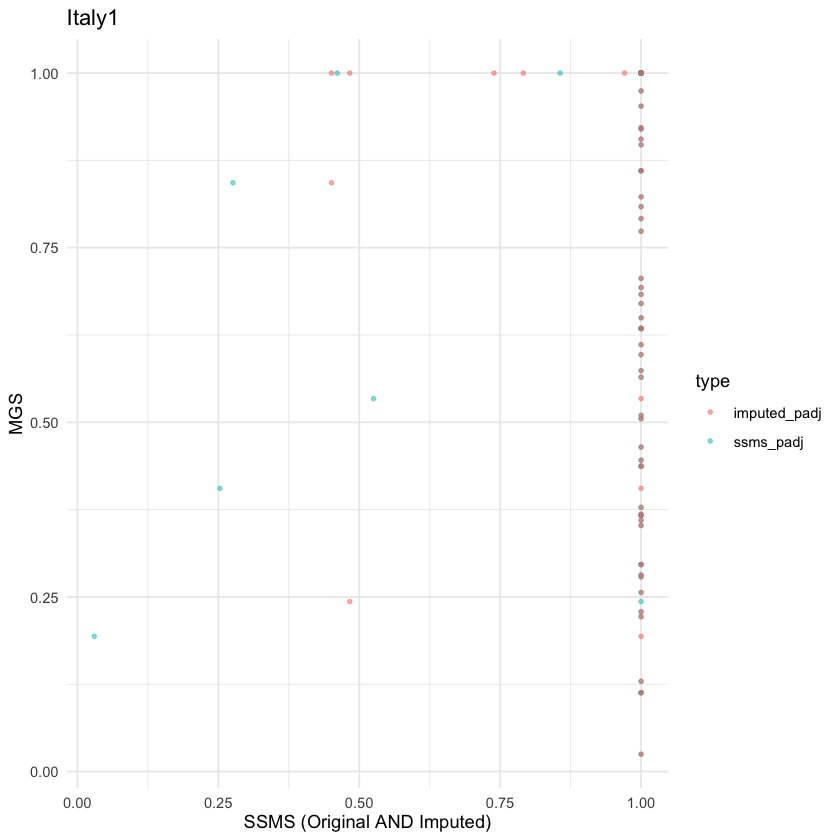

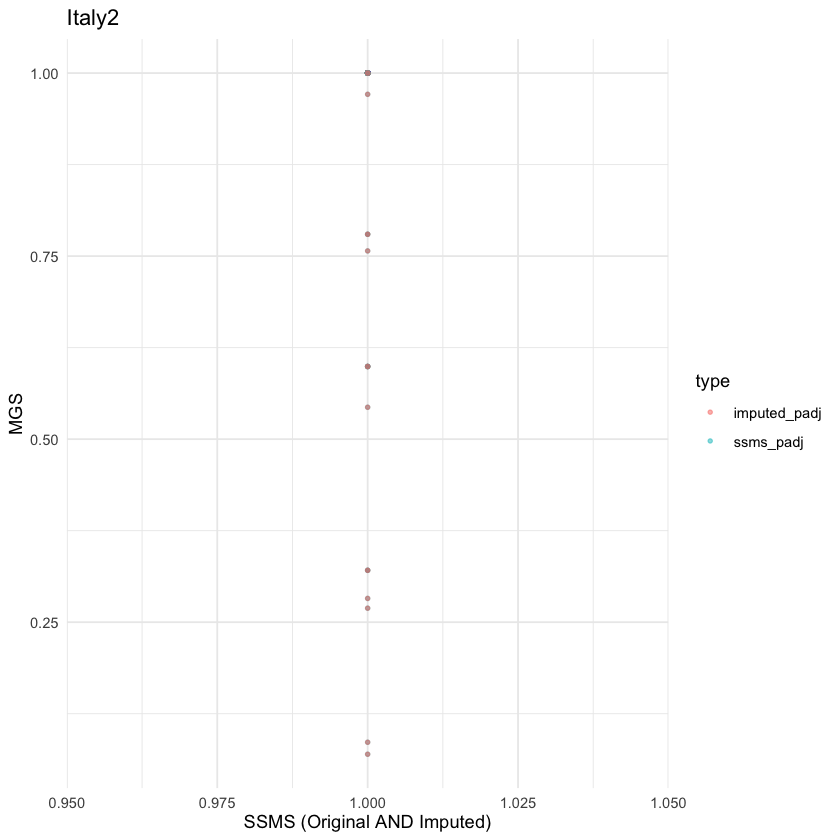

In [ ]:
pvalue_pw_Italy1asref_Italy2 <- calculate_pvalue(metadata = Italy2_metadata,
                                         mgs_matrix = dfs_aligned$Italy2_mgs_pw,
                                         shallow_matrix = dfs_aligned$Italy2_ssms_pw,
                                         imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy1asref_Italy2,
                                         condition_col = "study_condition",
                                         control_label = "control",
                                         crc_label = "CRC",
                                         group_id_col = "run_accession",
                                         set_names = c("MGS", "Shallow", "Imputed"))

pvalue_pw_Austriaasref_Italy2 <- calculate_pvalue(
  metadata = Italy2_metadata,
  mgs_matrix = dfs_aligned$Italy2_mgs_pw,
  shallow_matrix = dfs_aligned$Italy2_ssms_pw,
  imputed_matrix = dfs_aligned$predicted_pw_spiec_Austriaasref_Italy2,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

pvalue_pw_Italy2asref_Italy1 <- calculate_pvalue(metadata = Italy1_metadata,
                                         mgs_matrix = dfs_aligned$Italy1_mgs_pw,
                                         shallow_matrix = dfs_aligned$Italy1_ssms_pw,
                                         imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy2asref_Italy1,
                                         condition_col = "study_condition",
                                         control_label = "control",
                                         crc_label = "CRC",
                                         group_id_col = "run_accession",
                                         set_names = c("MGS", "Shallow", "Imputed"))

pvalue_pw_Austriaasref_Italy1 <- calculate_pvalue(metadata = Italy1_metadata,
                                          mgs_matrix = dfs_aligned$Italy1_mgs_pw,
                                          shallow_matrix = dfs_aligned$Italy1_ssms_pw,
                                          imputed_matrix = dfs_aligned$predicted_pw_spiec_Austriaasref_Italy1,
                                          condition_col = "study_condition",
                                          control_label = "control",
                                          crc_label = "CRC",
                                          group_id_col = "run_accession",
                                          set_names = c("MGS", "Shallow", "Imputed"))

pvalue_pw_Italy1asref_Austria <- calculate_pvalue(metadata = Austria_metadata,
                                          mgs_matrix = dfs_aligned$Austria_mgs_pw,
                                          shallow_matrix = dfs_aligned$Austria_ssms_pw,
                                          imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy1asref_Austria,
                                          condition_col = "study_condition",
                                          control_label = "control",
                                          crc_label = "CRC",
                                          group_id_col = "NCBI_accession",
                                          set_names = c("MGS", "Shallow", "Imputed"))

pvalue_pw_Italy2asref_Austria <- calculate_pvalue(metadata = Austria_metadata,
                                          mgs_matrix = dfs_aligned$Austria_mgs_pw,
                                          shallow_matrix = dfs_aligned$Austria_ssms_pw,
                                          imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy2asref_Austria,
                                          condition_col = "study_condition",
                                          control_label = "control",
                                          crc_label = "CRC",
                                          group_id_col = "NCBI_accession",
                                          set_names = c("MGS", "Shallow", "Imputed"))

pvalue_pw_Italy1asref_Italy2_long <- pivot_longer(pvalue_pw_Italy1asref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                              names_to = "type", values_to = "x_value")
pvalue_pw_Italy1asref_Austria_long <- pivot_longer(pvalue_pw_Italy1asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                               names_to = "type", values_to = "x_value")                      
pvalue_pw_Italy2asref_Austria_long <- pivot_longer(pvalue_pw_Italy2asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                               names_to = "type", values_to = "x_value")
pvalue_pw_Italy2asref_Italy1_long <- pivot_longer(pvalue_pw_Italy2asref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                              names_to = "type", values_to = "x_value")                      
pvalue_pw_Austriaasref_Italy2_long <- pivot_longer(pvalue_pw_Austriaasref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                               names_to = "type", values_to = "x_value")
pvalue_pw_Austriaasref_Italy1_long <- pivot_longer(pvalue_pw_Austriaasref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                               names_to = "type", values_to = "x_value")                      


ggplot(pvalue_pw_Italy1asref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")

ggplot(pvalue_pw_Italy1asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(pvalue_pw_Italy2asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(pvalue_pw_Italy2asref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(pvalue_pw_Austriaasref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(pvalue_pw_Austriaasref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")

In [ ]:
# ec-pvalue

pvalue_level4ec_Italy1asref_Italy2 <- calculate_pvalue(metadata = Italy2_metadata,
                                                 mgs_matrix = Italy2_mgs_level4ec,
                                                 shallow_matrix = Italy2_ssms_level4ec,
                                                 imputed_matrix = predicted_level4ec_spiec_Italy1asref_Italy2,
                                                 condition_col = "study_condition",
                                                 control_label = "control",
                                                 crc_label = "CRC",
                                                 group_id_col = "run_accession",
                                                 set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Austriaasref_Italy2 <- calculate_pvalue(
  metadata = Italy2_metadata,
  mgs_matrix = Italy2_mgs_level4ec,
  shallow_matrix = Italy2_ssms_level4ec,
  imputed_matrix = predicted_level4ec_spiec_Austriaasref_Italy2,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy2asref_Italy1 <- calculate_pvalue(metadata = Italy1_metadata,
                                                       mgs_matrix = Italy1_mgs_level4ec,
                                                       shallow_matrix = Italy1_ssms_level4ec,
                                                       imputed_matrix = predicted_level4ec_spiec_Italy2asref_Italy1,
                                                       condition_col = "study_condition",
                                                       control_label = "control",
                                                       crc_label = "CRC",
                                                       group_id_col = "run_accession",
                                                       set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Austriaasref_Italy1 <- calculate_pvalue(metadata = Italy1_metadata,
                                                        mgs_matrix = Italy1_mgs_level4ec,
                                                        shallow_matrix = Italy1_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Austriaasref_Italy1,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "run_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy1asref_Austria <- calculate_pvalue(metadata = Austria_metadata,
                                                        mgs_matrix = Austria_mgs_level4ec,
                                                        shallow_matrix = Austria_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Italy1asref_Austria,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "NCBI_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy2asref_Austria <- calculate_pvalue(metadata = Austria_metadata,
                                                        mgs_matrix = Austria_mgs_level4ec,
                                                        shallow_matrix = Austria_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Italy2asref_Austria,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "NCBI_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy1asref_Italy2_long <- pivot_longer(pvalue_level4ec_Italy1asref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                                        names_to = "type", values_to = "x_value")
pvalue_level4ec_Italy1asref_Austria_long <- pivot_longer(pvalue_level4ec_Italy1asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")                      
pvalue_level4ec_Italy2asref_Austria_long <- pivot_longer(pvalue_level4ec_Italy2asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")
pvalue_level4ec_Italy2asref_Italy1_long <- pivot_longer(pvalue_level4ec_Italy2asref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                                        names_to = "type", values_to = "x_value")                      
pvalue_level4ec_Austriaasref_Italy2_long <- pivot_longer(pvalue_level4ec_Austriaasref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")
pvalue_level4ec_Austriaasref_Italy1_long <- pivot_longer(pvalue_level4ec_Austriaasref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")                      


ggplot(pvalue_level4ec_Italy1asref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")

ggplot(pvalue_level4ec_Italy1asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(pvalue_level4ec_Italy2asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(pvalue_level4ec_Italy2asref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(pvalue_level4ec_Austriaasref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(pvalue_level4ec_Austriaasref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  # 
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")



ERROR: Error: Objekt 'Italy2_mgs_level4ec' nicht gefunden


In [ ]:
# ec - fc
fc_level4ec_Italy1asref_Italy2 <- calculate_fc(metadata = Italy2_metadata,
                                                       mgs_matrix = Italy2_mgs_level4ec,
                                                       shallow_matrix = Italy2_ssms_level4ec,
                                                       imputed_matrix = predicted_level4ec_spiec_Italy1asref_Italy2,
                                                       condition_col = "study_condition",
                                                       control_label = "control",
                                                       crc_label = "CRC",
                                                       group_id_col = "run_accession",
                                                       set_names = c("MGS", "Shallow", "Imputed"))

fc_level4ec_Austriaasref_Italy2 <- calculate_fc(
  metadata = Italy2_metadata,
  mgs_matrix = Italy2_mgs_level4ec,
  shallow_matrix = Italy2_ssms_level4ec,
  imputed_matrix = predicted_level4ec_spiec_Austriaasref_Italy2,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

fc_level4ec_Italy2asref_Italy1 <- calculate_fc(metadata = Italy1_metadata,
                                                       mgs_matrix = Italy1_mgs_level4ec,
                                                       shallow_matrix = Italy1_ssms_level4ec,
                                                       imputed_matrix = predicted_level4ec_spiec_Italy2asref_Italy1,
                                                       condition_col = "study_condition",
                                                       control_label = "control",
                                                       crc_label = "CRC",
                                                       group_id_col = "run_accession",
                                                       set_names = c("MGS", "Shallow", "Imputed"))

fc_level4ec_Austriaasref_Italy1 <- calculate_fc(metadata = Italy1_metadata,
                                                        mgs_matrix = Italy1_mgs_level4ec,
                                                        shallow_matrix = Italy1_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Austriaasref_Italy1,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "run_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

fc_level4ec_Italy1asref_Austria <- calculate_fc(metadata = Austria_metadata,
                                                        mgs_matrix = Austria_mgs_level4ec,
                                                        shallow_matrix = Austria_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Italy1asref_Austria,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "NCBI_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

fc_level4ec_Italy2asref_Austria <- calculate_fc(metadata = Austria_metadata,
                                                        mgs_matrix = Austria_mgs_level4ec,
                                                        shallow_matrix = Austria_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Italy2asref_Austria,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "NCBI_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

fc_level4ec_Italy1asref_Italy2_long <- pivot_longer(fc_level4ec_Italy1asref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                                        names_to = "type", values_to = "x_value")
fc_level4ec_Italy1asref_Austria_long <- pivot_longer(fc_level4ec_Italy1asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")                      
fc_level4ec_Italy2asref_Austria_long <- pivot_longer(fc_level4ec_Italy2asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")
fc_level4ec_Italy2asref_Italy1_long <- pivot_longer(fc_level4ec_Italy2asref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                                        names_to = "type", values_to = "x_value")                      
fc_level4ec_Austriaasref_Italy2_long <- pivot_longer(fc_level4ec_Austriaasref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")
fc_level4ec_Austriaasref_Italy1_long <- pivot_longer(fc_level4ec_Austriaasref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")                      


ggplot(fc_level4ec_Italy1asref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")

ggplot(fc_level4ec_Italy1asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(fc_level4ec_Italy2asref_Austria_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Austria")

ggplot(fc_level4ec_Italy2asref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(fc_level4ec_Austriaasref_Italy1_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy1")

ggplot(fc_level4ec_Austriaasref_Italy2_long, aes(x = x_value, y = mgs_padj, shape = type, color = type)) +
  geom_point(alpha = 0.5) +
  scale_shape_manual(values = c(20, 20)) +  
  theme_minimal() +
  labs(x = "SSMS (Original AND Imputed)",
       y = "MGS",
       title = "Italy2")



In [13]:
source("utilities.R")

pvalue_level4ec_Italy1asref_Italy2 <- calculate_pvalue(metadata = Italy2_metadata,
                                                 mgs_matrix = dfs_aligned$Italy2_mgs_pw,
                                                 shallow_matrix = dfs_aligned$Italy2_ssms_pw,
                                                 imputed_matrix = dfs_aligned$predicted_pw_spiec_Italy1asref_Italy2,
                                                 condition_col = "study_condition",
                                                 control_label = "control",
                                                 crc_label = "CRC",
                                                 group_id_col = "run_accession",
                                                 set_names = c("MGS", "Shallow", "Imputed"))
str(pvalue_level4ec_Italy1asref_Italy2)
table(pvalue_level4ec_Italy1asref_Italy2$mgs_padj < 0.1)
table(pvalue_level4ec_Italy1asref_Italy2$ssms_padj < 0.1)
table(pvalue_level4ec_Italy1asref_Italy2$imputed_padj < 0.1)   

Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warning message in wilcox.test.default(as.matrix(ctrl_mat)[i, ], as.matrix(crc_mat)[i, :
"kann bei Bindungen keinen exakten p-Wert Berechnen"
Warnin

'data.frame':	203 obs. of  3 variables:
 $ mgs_padj    : num  1 1 1 1 1 1 1 1 1 1 ...
 $ ssms_padj   : num  1 1 1 1 1 1 1 1 1 1 ...
 $ imputed_padj: num  1 1 1 1 1 1 1 1 1 1 ...



FALSE  TRUE 
  201     2 


FALSE 
  203 


FALSE  TRUE 
  202     1 

In [ ]:
# pathway - pvalue
source("utilities.R")
#dfs_aligned$predicted_pw_spiec_Austriaasref_Italy2
pvalue_level4ec_Italy1asref_Italy2 <- calculate_pvalue(metadata = Italy2_metadata,
                                                 mgs_matrix = Italy2_mgs_pw,
                                                 shallow_matrix = Italy2_ssms_pw,
                                                 imputed_matrix = predicted_pw_spiec_Italy1asref_Italy2,
                                                 condition_col = "study_condition",
                                                 control_label = "control",
                                                 crc_label = "CRC",
                                                 group_id_col = "run_accession",
                                                 set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Austriaasref_Italy2 <- calculate_pvalue(
  metadata = Italy2_metadata,
  mgs_matrix = Italy2_mgs_level4ec,
  shallow_matrix = Italy2_ssms_level4ec,
  imputed_matrix = predicted_level4ec_spiec_Austriaasref_Italy2,
  condition_col = "study_condition",
  control_label = "control",
  crc_label = "CRC",
  group_id_col = "run_accession",
  set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy2asref_Italy1 <- calculate_pvalue(metadata = Italy1_metadata,
                                                       mgs_matrix = Italy1_mgs_level4ec,
                                                       shallow_matrix = Italy1_ssms_level4ec,
                                                       imputed_matrix = predicted_level4ec_spiec_Italy2asref_Italy1,
                                                       condition_col = "study_condition",
                                                       control_label = "control",
                                                       crc_label = "CRC",
                                                       group_id_col = "run_accession",
                                                       set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Austriaasref_Italy1 <- calculate_pvalue(metadata = Italy1_metadata,
                                                        mgs_matrix = Italy1_mgs_level4ec,
                                                        shallow_matrix = Italy1_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Austriaasref_Italy1,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "run_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy1asref_Austria <- calculate_pvalue(metadata = Austria_metadata,
                                                        mgs_matrix = Austria_mgs_level4ec,
                                                        shallow_matrix = Austria_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Italy1asref_Austria,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "NCBI_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy2asref_Austria <- calculate_pvalue(metadata = Austria_metadata,
                                                        mgs_matrix = Austria_mgs_level4ec,
                                                        shallow_matrix = Austria_ssms_level4ec,
                                                        imputed_matrix = predicted_level4ec_spiec_Italy2asref_Austria,
                                                        condition_col = "study_condition",
                                                        control_label = "control",
                                                        crc_label = "CRC",
                                                        group_id_col = "NCBI_accession",
                                                        set_names = c("MGS", "Shallow", "Imputed"))

pvalue_level4ec_Italy1asref_Italy2_long <- pivot_longer(pvalue_level4ec_Italy1asref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                                        names_to = "type", values_to = "x_value")
pvalue_level4ec_Italy1asref_Austria_long <- pivot_longer(pvalue_level4ec_Italy1asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")                      
pvalue_level4ec_Italy2asref_Austria_long <- pivot_longer(pvalue_level4ec_Italy2asref_Austria, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")
pvalue_level4ec_Italy2asref_Italy1_long <- pivot_longer(pvalue_level4ec_Italy2asref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                                        names_to = "type", values_to = "x_value")                      
pvalue_level4ec_Austriaasref_Italy2_long <- pivot_longer(pvalue_level4ec_Austriaasref_Italy2, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")
pvalue_level4ec_Austriaasref_Italy1_long <- pivot_longer(pvalue_level4ec_Austriaasref_Italy1, cols = c(ssms_padj, imputed_padj), 
                                                         names_to = "type", values_to = "x_value")                      





Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.1 erstellt"


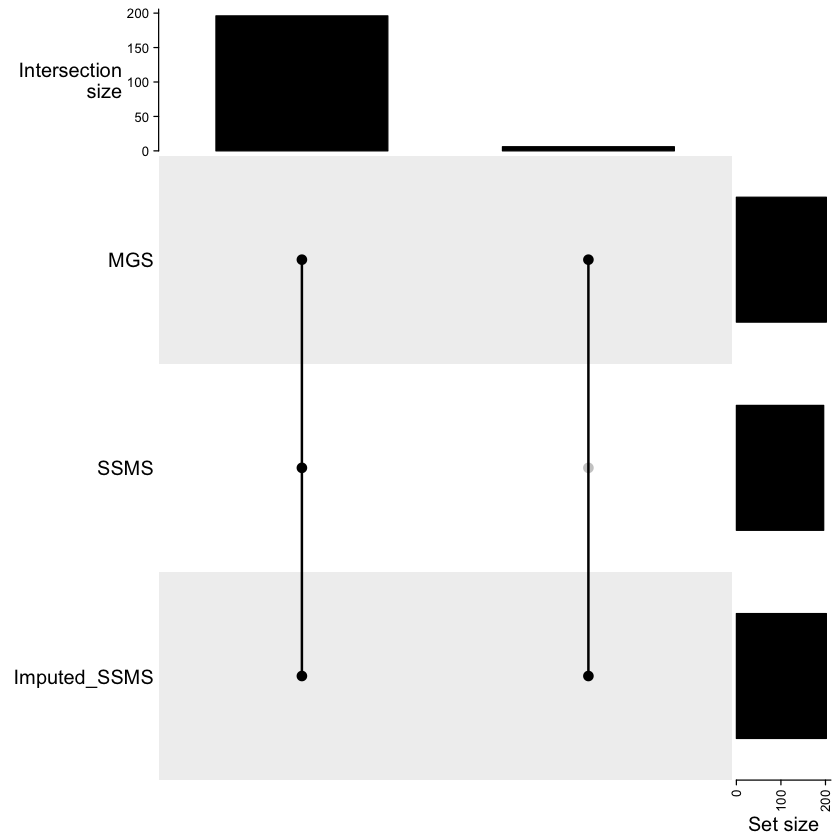

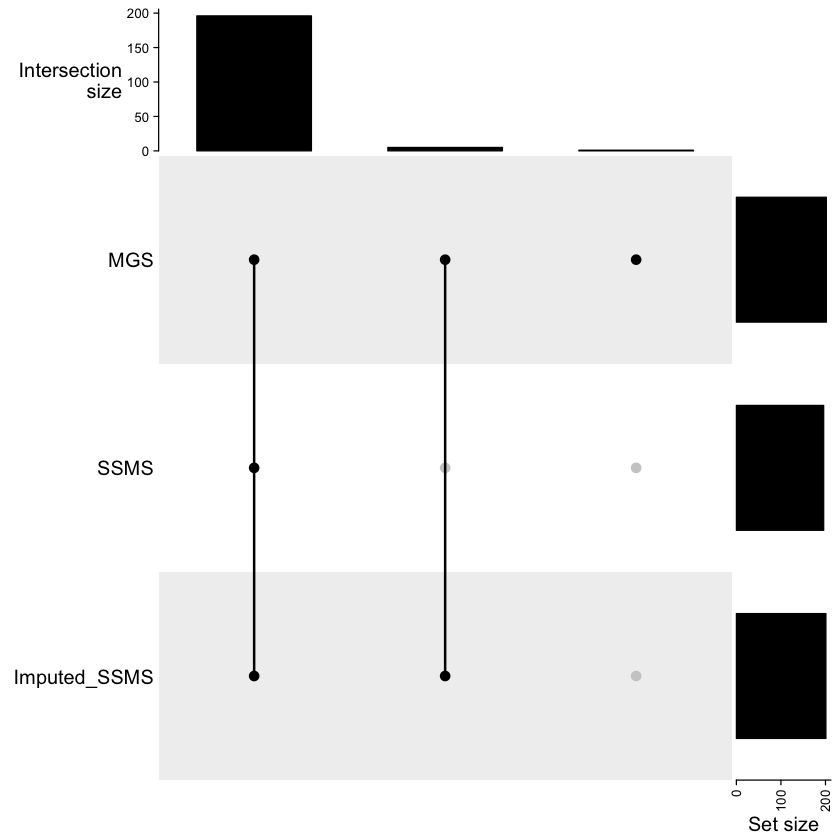

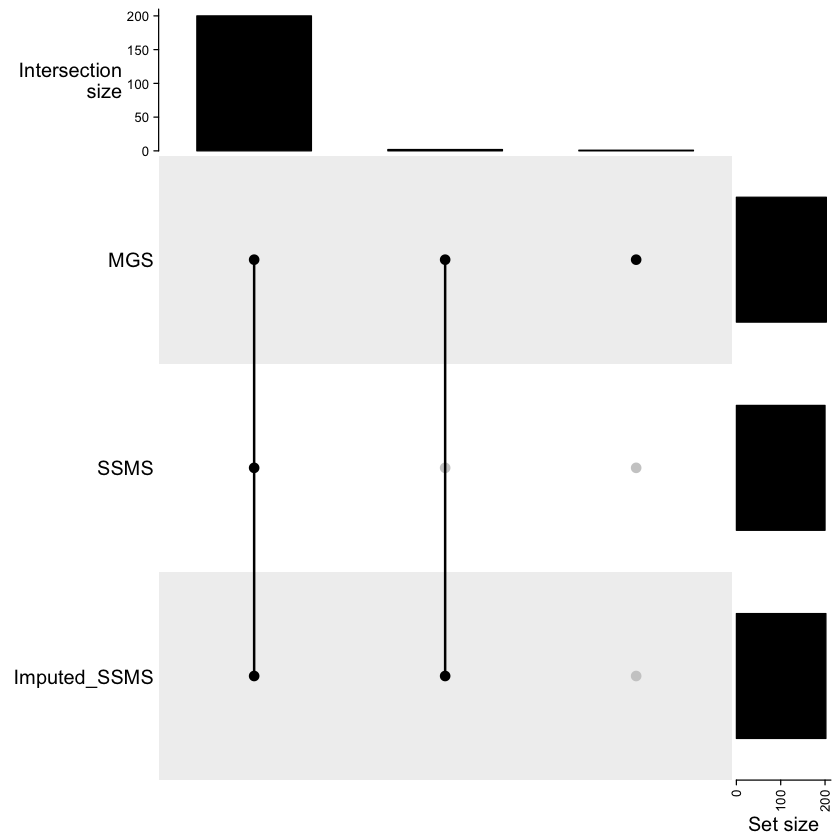

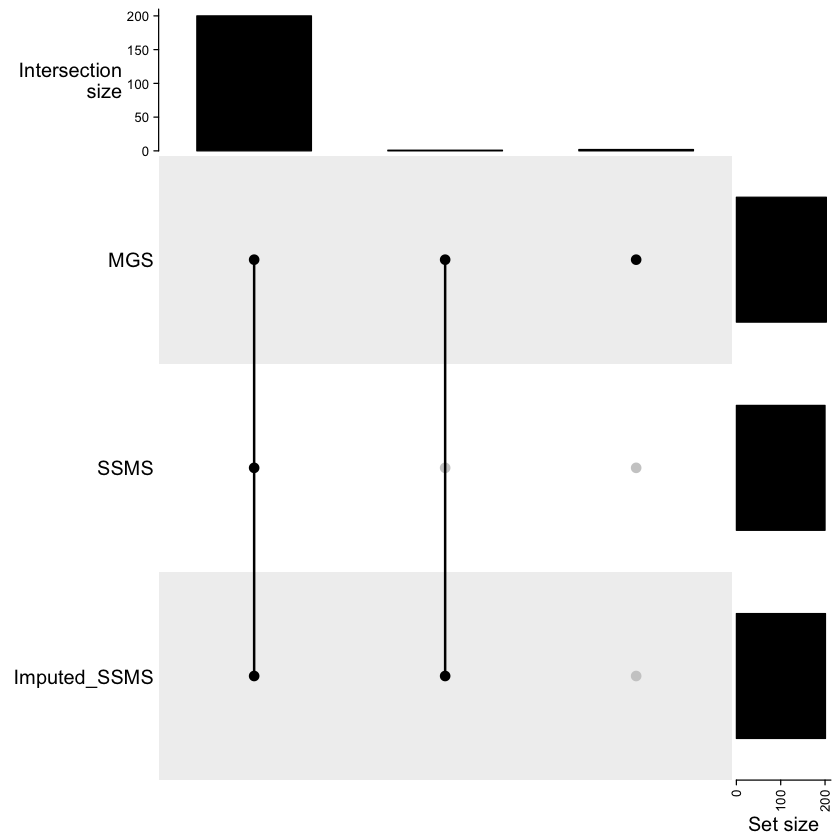

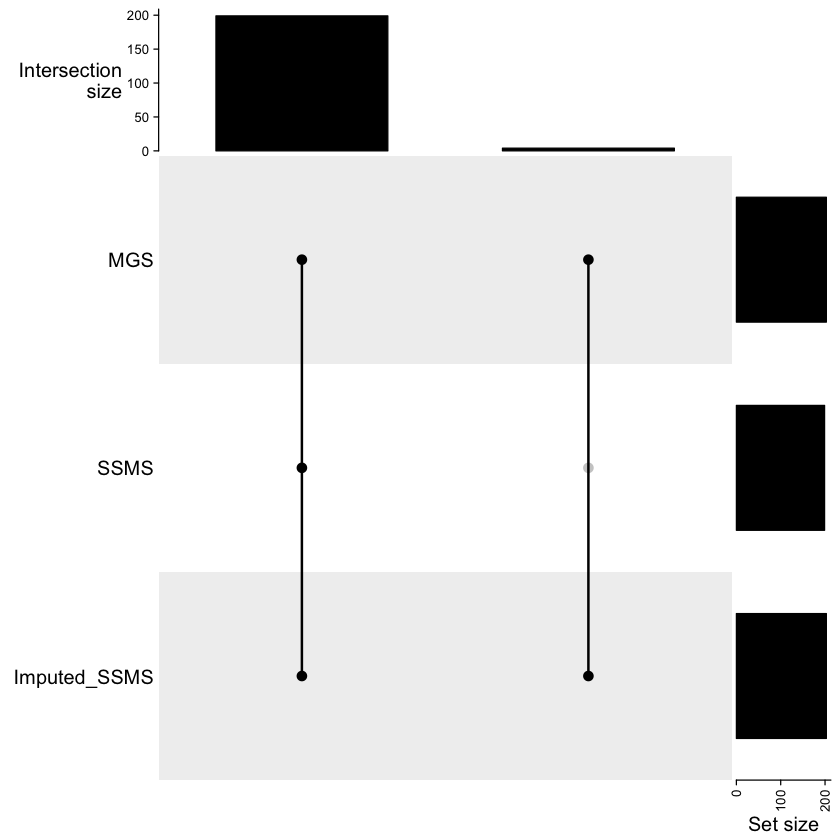

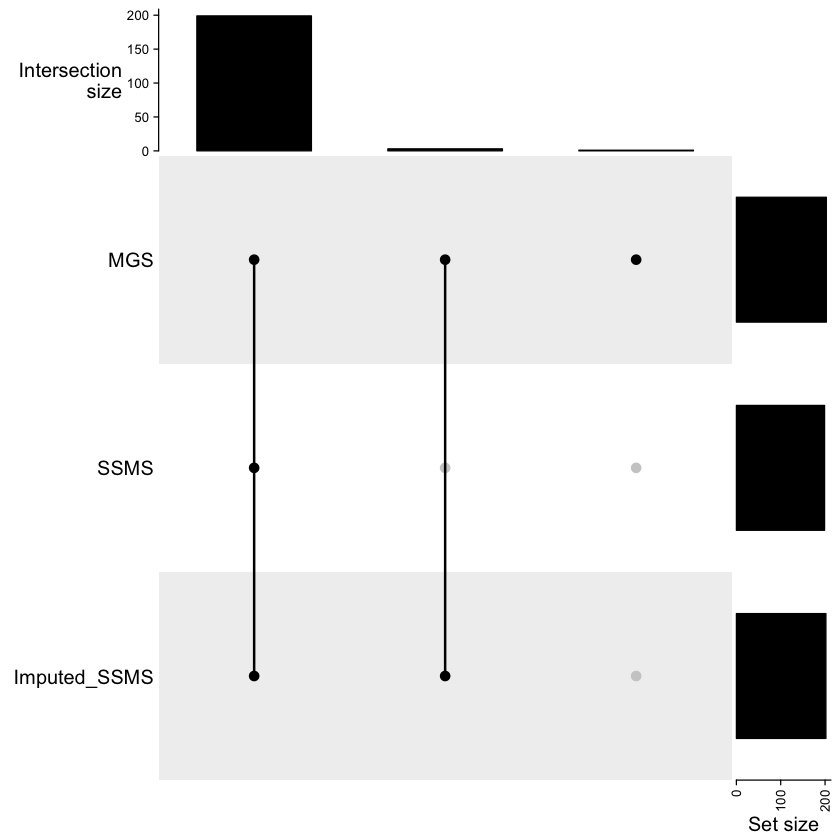

In [18]:
library(VennDiagram)
library(eulerr)
library(UpSetR)
library(ComplexHeatmap)

source("utilities.R")

# Italy1asref_Italy2 
plot_upset(list(
  "MGS" = Italy2_mgs_pw,
  "SSMS" = Italy2_ssms_pw,
  "Imputed_SSMS" = predicted_pw_spiec_Italy1asref_Italy2
))

# Austriaasref_Italy2
plot_upset(list(
  "MGS" = Italy2_mgs_pw,
  "SSMS" = Italy2_ssms_pw,  
  "Imputed_SSMS" = predicted_pw_spiec_Austriaasref_Italy2
))  

# Italy2asref_Italy1
plot_upset(list(
  "MGS" = Italy1_mgs_pw,
  "SSMS" = Italy1_ssms_pw,  
  "Imputed_SSMS" = predicted_pw_spiec_Italy2asref_Italy1  
))

# Austriaasref_Italy1
plot_upset(list(
  "MGS" = Italy1_mgs_pw,
  "SSMS" = Italy1_ssms_pw,
  "Imputed_SSMS" = predicted_pw_spiec_Austriaasref_Italy1
))  

# Italy1asref_Austria
plot_upset(list(
  "MGS" = Austria_mgs_pw, 
  "SSMS" = Austria_ssms_pw,
  "Imputed_SSMS" = predicted_pw_spiec_Italy1asref_Austria 
))

# Italy2asref_Austria
plot_upset(list(
  "MGS" = Austria_mgs_pw,
  "SSMS" = Austria_ssms_pw, 
  "Imputed_SSMS" = predicted_pw_spiec_Italy2asref_Austria
))  


In [6]:
# test
non_null_sets <- lapply(list(
  "MGS" = Italy2_mgs_pw,
  "SSMS" = Italy2_ssms_pw,  
  "Imputed_SSMS" = predicted_pw_spiec_Italy1asref_Italy2  
), function(mat) {
   degs <- rowSums(mat != 0)
   names(degs[degs > 0])
 })

mgs <- non_null_sets[[1]]
ssms <- non_null_sets[[2]]
Imputed_SSMS <- non_null_sets[[3]]

str(non_null_sets)

length(intersect(mgs, ssms))
length(intersect(mgs, Imputed_SSMS))
length(intersect(ssms, Imputed_SSMS))

List of 3
 $ MGS         : chr [1:202] "PHOSLIPSYN-PWY" "PWY-5981" "PWY0-1319" "PWY4FS-7" ...
 $ SSMS        : chr [1:196] "PHOSLIPSYN-PWY" "PWY0-1319" "PWY4FS-7" "COLANSYN-PWY" ...
 $ Imputed_SSMS: chr [1:202] "PHOSLIPSYN-PWY" "PWY-5981" "PWY0-1319" "PWY4FS-7" ...


[1] 196

[1] 202

[1] 196